# EDA — OP_AURUM_extract.csv

Analisis exploratorio del extracto de telemetria OPUS-MINE de la Unidad Minera La Cornisa.
El notebook recorre **una variable por seccion**, en el orden en que se entienden y no en el
del archivo: primero el tiempo y la ubicacion, luego la ley y lo que se deriva de ella,
despues los sensores de perforacion y por ultimo las fallas y los actores. Cada seccion
describe la variable, la contrasta con lo que dice el diccionario y deja constancia de donde
el dato lo contradice.

El diccionario de variables y el analisis conceptual estan en `docs/diccionario_variables.md`.

**Figuras.** Son estaticas, de seaborn sobre matplotlib, y quedan embebidas como imagen
en el propio notebook: se ven en GitHub, en Jupyter y en VS Code sin ejecutar nada. Todas
comparten ancho y estilo, con titulo que enuncia el hallazgo y ejes rotulados con su unidad.

**Ejecucion.** El CSV es dato de negocio y no se versiona. El notebook lo busca en la
variable de entorno `AURUM_CSV_PATH`, luego en el directorio `data/` del repositorio
—ignorado por git— y por ultimo en un directorio `insumos/` hermano.

<a id="indice"></a>

## Sintesis e indice

Cada fila enlaza a la seccion de la variable. El detalle, las figuras y las cifras que
sostienen cada hallazgo estan ahi; esta tabla es el resumen para leer primero y el indice
para volver despues.

| Variable | Hallazgo | Evidencia |
|---|---|---|
| [`ts_opus_utc`](#ts_opus_utc) | el extracto cubre 27.9 meses, no los 18 del enunciado | 2023-07-01 a 2025-10-28 |
| [`ts_opus_utc`](#ts_opus_utc) | flujo estrictamente serial: se adopta el supuesto de extracto sintetico | cadencia uniforme de 15 a 34 min, cero eventos simultaneos |
| [`turno_cod`](#turno_cod) | es funcion determinista de la hora, con desfase de cinco horas | cada hora UTC cae en un unico turno |
| [`frente_id`](#frente_id) | es la variable que mas separa la ley | medias de 2.9 a 15.3 g/t |
| [`frente_id`](#frente_id) | la ley es el nivel del frente mas ruido blanco | R2 = 0.83 con solo la media del frente; autocorrelacion residual -0.001 |
| [`sector_geol`](#sector_geol) | misma jerarquia que el frente, mas gruesa | cada frente pertenece a un unico sector |
| [`tipo_mineral`](#tipo_mineral) | no discrimina la ley; determina la recuperacion | rango de medias de 0.06 g/t |
| [`ley_au_gpT`](#ley_au_gpT) | usa `-1.0` como centinela de "sin lectura" | unico valor negativo, 2810 registros (5.6%) |
| [`ley_au_gpT`](#ley_au_gpT) | el faltante no es aleatorio | 16.1% en N2 contra ~2.1% en el resto |
| [`ley_au_gpT`](#ley_au_gpT) | es heterocedastica y simetrica: se resume con la media | corr(media, desviacion) = 1.00; coef. de variacion 0.18 en los 13 frentes |
| [`ton_rom_acum`](#ton_rom_acum) | no es un acumulado pese a su nombre | creciente en 4.0% de los grupos |
| [`prod_estimada_oz`](#prod_estimada_oz) | es funcion determinista de la ley | R2 = 0.999999999972; nula donde la ley es centinela |
| [`pres_hidraul_bar`](#pres_hidraul_bar) | excedencia frecuente y poco informativa | 9.5% fuera de banda, 4.3% de falla contra 3.3% base |
| [`rpm_corona`](#rpm_corona) | nunca sale de su rango | 0 registros fuera de 800-1400 |
| [`avance_mmin`](#avance_mmin), [`agua_iny_lmin`](#agua_iny_lmin) | distribuciones limpias, sin relacion con la ley | correlaciones por debajo de 0.01 |
| [`vibracion_rms_ms2`](#vibracion_rms_ms2) | excedencia rara y muy informativa, independiente de la temperatura | 0.28% sobre 12 m/s2, con 17.1% de falla; solo 19% de solape con la alerta termica |
| [`temp_motor_c`](#temp_motor_c) | asociacion mas fuerte con la falla, dentro del mismo registro | 22.0% de falla sobre 95 C contra 3.3% base |
| [`temp_motor_c`](#temp_motor_c) | el umbral real es 88 C, no los 95 C del diccionario | escalon en 88 C; captura el 49% de las fallas contra el 12% del umbral publicado |
| [`falla_cod`](#falla_cod) | evento raro y repartido entre subsistemas | 3.32%, ocho codigos de 192 a 227 eventos |
| [`falla_cod`](#falla_cod) | la falla a 4 horas no es predecible; la deteccion contemporanea si | ninguna condicion mueve la tasa de 3.05%; sobre 88 C hay 22.7% en el mismo registro |
| [`flag_mant_prev`](#flag_mant_prev) | sin poder discriminante: la diferencia no se distingue del azar | 2.80% contra 3.33%; z = -1.01, p = 0.31 |
| [`equipo_id`](#equipo_id) | etiqueta sin contenido: no admite lectura causal | ley y falla planas entre equipos; cada equipo en los 13 frentes |
| [`op_id`](#op_id) | etiqueta sin contenido: no admite lectura causal | ley plana entre operadores; cada operador en los 10 equipos |

**Secciones.** [1. El extracto completo](#extracto) · [2. `ts_opus_utc`](#ts_opus_utc) ·
[3. `turno_cod`](#turno_cod) · [4. `frente_id`](#frente_id) · [5. `sector_geol`](#sector_geol) ·
[6. `tipo_mineral`](#tipo_mineral) · [7. `ley_au_gpT`](#ley_au_gpT) ·
[8. `ton_rom_acum`](#ton_rom_acum) · [9. `prod_estimada_oz`](#prod_estimada_oz) ·
[10. `pres_hidraul_bar`](#pres_hidraul_bar) · [11. `rpm_corona`](#rpm_corona) ·
[12. `avance_mmin`](#avance_mmin) · [13. `agua_iny_lmin`](#agua_iny_lmin) ·
[14. `vibracion_rms_ms2`](#vibracion_rms_ms2) · [15. `temp_motor_c`](#temp_motor_c) ·
[16. `falla_cod`](#falla_cod) · [17. `flag_mant_prev`](#flag_mant_prev) ·
[18. `equipo_id`](#equipo_id) · [19. `op_id`](#op_id)

In [1]:
"""Herramientas del analisis exploratorio del extracto OPUS.

Este notebook sigue la rubrica de codigo del proyecto: cada pieza reutilizable es una
clase con una responsabilidad unica, las firmas estan anotadas, los docstrings explican
por que existe cada decision, y las afirmaciones del texto se respaldan con
verificaciones ejecutables en lugar de quedar como promesa.

Se organiza en cuatro piezas:

- `Paleta`   : roles semanticos de color y el estilo unico de las figuras.
- `Extracto` : carga del CSV, mascaras derivadas y constantes del dominio.
- `Graficos` : constructor de figuras, una por tipo de lectura.
- `Analisis` : calculos que se repiten entre secciones.

Las figuras son de seaborn sobre matplotlib y no interactivas a proposito: se renderizan
como imagen dentro del propio notebook, de modo que quien revise el repositorio en GitHub
las ve sin ejecutar nada ni instalar nada.
"""

from __future__ import annotations

import math
import os
from collections.abc import Mapping, Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import Final

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


@dataclass(frozen=True)
class Paleta:
    """Roles semanticos de color y estilo, no valores sueltos repartidos por el notebook.

    Las figuras nombran el rol (`serie`, `critico`, `apagado`) y nunca un codigo
    hexadecimal, de modo que cambiar la identidad visual del notebook es editar esta clase.
    Es inmutable porque un color que cambia a mitad del documento produce dos figuras que
    dicen cosas distintas con el mismo tono.
    """

    tinta: str = "#0b0b0b"
    apagado: str = "#898781"
    rejilla: str = "#e1e0d9"
    superficie: str = "#fcfcfb"
    critico: str = "#d03b3b"
    series: tuple[str, ...] = ("#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")

    def aplicar_estilo(self) -> None:
        """Fija el tema de seaborn una sola vez, para que todas las figuras alineen.

        El ancho, la tipografia y el tamano de titulo son comunes a todo el notebook: dos
        figuras con anchos distintos se leen como dos documentos distintos, y comparar entre
        secciones se vuelve incomodo sin motivo.
        """
        sns.set_theme(
            style="whitegrid",
            rc={
                "figure.facecolor": self.superficie,
                "axes.facecolor": self.superficie,
                "axes.edgecolor": self.apagado,
                "axes.labelcolor": self.tinta,
                "axes.labelsize": 10,
                "axes.titlesize": 12,
                "axes.titleweight": "bold",
                "axes.titlecolor": self.tinta,
                "axes.titlepad": 10,
                "axes.grid": True,
                "grid.color": self.rejilla,
                "grid.linewidth": 0.8,
                "text.color": self.tinta,
                "xtick.color": self.apagado,
                "ytick.color": self.apagado,
                "xtick.labelsize": 9,
                "ytick.labelsize": 9,
                "font.size": 10,
                "figure.dpi": 110,
                "savefig.facecolor": self.superficie,
                "legend.frameon": False,
                "figure.constrained_layout.use": True,
            },
        )
        sns.set_palette(list(self.series))

    @property
    def mapa_divergente(self) -> mpl.colors.LinearSegmentedColormap:
        """Mapa continuo para correlaciones: azul negativo, superficie en cero, rojo positivo."""
        return mpl.colors.LinearSegmentedColormap.from_list(
            "aurum_div", [self.series[0], self.superficie, self.critico])

    @property
    def mapa_secuencial(self) -> mpl.colors.LinearSegmentedColormap:
        """Mapa continuo para conteos, de la superficie al azul oscuro."""
        return mpl.colors.LinearSegmentedColormap.from_list(
            "aurum_seq", [self.superficie, "#9ecae1", self.series[0], "#123b6d"])


PALETA = Paleta()
PALETA.aplicar_estilo()

In [2]:
class Extracto:
    """El extracto OPUS cargado, con sus mascaras derivadas y el dominio que lo describe.

    Existe para que ninguna seccion vuelva a decidir que es un centinela, cual es el desfase
    horario o que registros tienen lectura valida: se decide una vez, aqui, y todas las
    secciones leen la misma verdad. Las constantes son del dominio minero y no de la
    implementacion, por eso viven en la clase y no dispersas en las celdas.
    """

    CENTINELA_LEY: Final[float] = -1.0
    DESFASE_LOCAL_HORAS: Final[int] = 5
    OZ_TROY_EN_GRAMOS: Final[float] = 31.1035
    RANGOS_DICCIONARIO: Final[Mapping[str, tuple[float | None, float | None, str]]] = {
        "pres_hidraul_bar": (180.0, 240.0, "rango normal"),
        "rpm_corona": (800.0, 1400.0, "rango operacional"),
        "vibracion_rms_ms2": (None, 12.0, "alerta operacional"),
        "temp_motor_c": (None, 95.0, "apagado automatico"),
    }
    SENSORES: Final[tuple[str, ...]] = (
        "pres_hidraul_bar", "rpm_corona", "avance_mmin",
        "agua_iny_lmin", "vibracion_rms_ms2", "temp_motor_c",
    )

    def __init__(self, ruta: Path | None = None) -> None:
        self.ruta: Path = ruta if ruta is not None else self.localizar()
        self.datos: pd.DataFrame = pd.read_csv(self.ruta, parse_dates=["ts_opus_utc"])
        self.columnas_originales: tuple[str, ...] = tuple(self.datos.columns)
        self.datos["ley_sentinela"] = self.datos["ley_au_gpT"].eq(self.CENTINELA_LEY)
        self.datos["falla"] = self.datos["falla_cod"].notna()
        self.datos["fecha_local"] = (
            self.datos["ts_opus_utc"] - pd.Timedelta(hours=self.DESFASE_LOCAL_HORAS)
        ).dt.date

    @staticmethod
    def localizar(nombre: str = "OP_AURUM_extract.csv") -> Path:
        """Ubica el CSV sin escribir rutas absolutas en el notebook.

        El extracto es dato de negocio y no se versiona, de modo que la ruta no puede vivir
        en el codigo. Se busca en este orden: la variable de entorno `AURUM_CSV_PATH`, el
        directorio `data/` del repositorio (ignorado por git) y, como ultimo recurso, un
        directorio `insumos/` hermano del repositorio.
        """
        del_entorno = os.environ.get("AURUM_CSV_PATH")
        if del_entorno:
            return Path(del_entorno).expanduser().resolve()
        aqui = Path.cwd().resolve()
        for padre in [aqui, *aqui.parents]:
            for candidato in (padre / "data" / nombre,
                              padre / "insumos" / nombre,
                              padre.parent / "insumos" / nombre):
                if candidato.exists():
                    return candidato.resolve()
        raise FileNotFoundError(
            f"No se encontro {nombre}. Copialo en data/ o define AURUM_CSV_PATH.")

    @property
    def crudo(self) -> pd.DataFrame:
        """El archivo tal como llego, sin las columnas derivadas que agrega esta clase.

        Las derivadas son comodidad del analisis y no parte del extracto: mezclarlas
        falsearia cualquier conteo de columnas o de completitud.
        """
        return self.datos[list(self.columnas_originales)]

    @property
    def validos(self) -> pd.DataFrame:
        """Registros con lectura valida de ley: los unicos sobre los que se promedia."""
        return self.datos.loc[~self.datos["ley_sentinela"]]

    @property
    def n_filas(self) -> int:
        """Cantidad de registros del extracto."""
        return len(self.datos)

    def fuera_de_rango(self, columna: str) -> pd.Series:
        """Mascara de excedencia del rango publicado en el diccionario para un sensor."""
        minimo, maximo, _ = self.RANGOS_DICCIONARIO[columna]
        serie = self.datos[columna]
        fuera = pd.Series(False, index=self.datos.index)
        if minimo is not None:
            fuera |= serie < minimo
        if maximo is not None:
            fuera |= serie > maximo
        return fuera

    def cadencia_global(self) -> pd.Series:
        """Minutos entre eventos consecutivos del archivo, sin separar por frente."""
        return self.datos["ts_opus_utc"].diff().dt.total_seconds().div(60).dropna()

    def cadencia_por_frente(self) -> pd.Series:
        """Minutos entre eventos consecutivos de un mismo frente."""
        ordenado = self.datos.sort_values("ts_opus_utc")
        return (ordenado.groupby("frente_id")["ts_opus_utc"]
                        .diff().dt.total_seconds().div(60).dropna())

    def actividad_por_frente_y_mes(self) -> pd.DataFrame:
        """Matriz frente x mes con el conteo de registros, base del mapa de huecos."""
        periodo = self.datos["ts_opus_utc"].dt.to_period("M")
        return (self.datos.groupby(["frente_id", periodo]).size()
                    .unstack(fill_value=0).sort_index())


extracto = Extracto()
df = extracto.datos          # alias corto para las celdas de exploracion
valida = extracto.validos

print(f"origen  : {extracto.ruta}")
print(f"filas   : {extracto.n_filas:,}")
print(f"columnas: {len(extracto.columnas_originales)}")

origen  : /Users/amadorcallelo/projects/personal/pruebas_tecnicas/mineros/data_scientist_senior/repositorio-ds-mine/data/OP_AURUM_extract.csv
filas   : 50,000
columnas: 18


In [3]:
class Graficos:
    """Constructor de las figuras del notebook, una por tipo de lectura.

    Cada metodo dibuja una figura completa —titulo principal que dice el hallazgo, ejes
    rotulados con su unidad— y la muestra. Existe para que ninguna celda del notebook
    contenga codigo de presentacion y para que todas las figuras compartan ancho, estilo y
    jerarquia tipografica: comparar entre secciones exige que el ojo no tenga que
    reacomodarse en cada figura.
    """

    ANCHO: Final[float] = 9.4          # pulgadas, comun a todas las figuras
    ANCHO_ESTRECHO: Final[float] = 6.0

    def __init__(self, paleta: Paleta = PALETA) -> None:
        self.paleta = paleta

    def _rotular(self, eje: plt.Axes, titulo: str, etiqueta_x: str = "",
                 etiqueta_y: str = "") -> None:
        """Titulo alineado a la izquierda y ejes rotulados: el minimo de toda figura."""
        eje.set_title(titulo, loc="left")
        eje.set_xlabel(etiqueta_x)
        eje.set_ylabel(etiqueta_y)

    def _limites(self, eje: plt.Axes, limites: Sequence[float | None],
                 etiqueta: str | None = None) -> None:
        """Dibuja los limites del diccionario como lineas punteadas de alerta."""
        for limite in limites:
            if limite is None:
                continue
            eje.axvline(limite, color=self.paleta.critico, linewidth=1.6, linestyle="--",
                        label=etiqueta)
            etiqueta = None

    def histograma_y_caja(self, serie: pd.Series, titulo: str, etiqueta_x: str,
                          limites: Sequence[float | None] = (), bins: int = 50,
                          etiqueta_limite: str | None = None) -> None:
        """Histograma sobre diagrama de caja, compartiendo el eje horizontal.

        Se muestran juntos porque responden preguntas distintas de la misma variable: el
        histograma revela modas y cortes, la caja revela mediana, cuartiles y atipicos.
        Separarlos obliga a comparar dos figuras con escalas que no coinciden.
        """
        _figura, ejes = plt.subplots(2, 1, figsize=(self.ANCHO, 3.9), sharex=True,
                                    height_ratios=[3, 1])
        sns.histplot(x=serie.dropna(), bins=bins, color=self.paleta.series[0],
                     edgecolor=self.paleta.superficie, linewidth=0.4, ax=ejes[0])
        self._rotular(ejes[0], titulo, "", "registros")
        sns.boxplot(x=serie.dropna(), color=self.paleta.series[0], width=0.5,
                    fliersize=2, linecolor=self.paleta.tinta, linewidth=1, ax=ejes[1])
        self._rotular(ejes[1], "", etiqueta_x, "")
        ejes[1].set_yticks([])
        for eje in ejes:
            self._limites(eje, limites, etiqueta_limite)
        if etiqueta_limite:
            ejes[0].legend(loc="upper right")
        plt.show()

    def barras_horizontales(self, etiquetas: Sequence[str], valores: Sequence[float],
                            titulo: str, etiqueta_x: str, etiqueta_y: str = "",
                            formato: str = "{:.2f}", color: str | None = None,
                            alto_por_barra: float = 0.34) -> None:
        """Ranking horizontal con el valor anotado al final de cada barra."""
        alto = max(2.2, alto_por_barra * len(list(etiquetas)) + 1.3)
        _figura, eje = plt.subplots(figsize=(self.ANCHO, alto))
        barras = eje.barh(list(etiquetas), list(valores),
                          color=color or self.paleta.series[0], height=0.62)
        eje.bar_label(barras, labels=[formato.format(v) for v in valores],
                      padding=4, color=self.paleta.tinta, fontsize=9)
        maximo = max(list(valores)) if len(list(valores)) else 1
        eje.set_xlim(0 if min(valores) >= 0 else None, maximo * 1.18)
        self._rotular(eje, titulo, etiqueta_x, etiqueta_y)
        eje.grid(axis="y", visible=False)
        plt.show()

    def matriz_correlacion(self, matriz: pd.DataFrame, titulo: str,
                           etiqueta_escala: str) -> None:
        """Matriz de correlacion anotada, con la escala fija en [-1, 1].

        La escala se fija a proposito: sin fijarla, una matriz sin correlaciones se colorea
        igual que una llena de ellas y el lector concluye lo contrario de lo que hay.
        """
        _figura, eje = plt.subplots(figsize=(self.ANCHO, 7.2))
        sns.heatmap(matriz, vmin=-1, vmax=1, cmap=self.paleta.mapa_divergente,
                    annot=True, fmt=".2f", annot_kws={"fontsize": 8}, square=True,
                    linewidths=0.6, linecolor=self.paleta.superficie,
                    cbar_kws={"label": etiqueta_escala, "shrink": 0.75}, ax=eje)
        self._rotular(eje, titulo, "variable", "variable")
        eje.tick_params(axis="x", rotation=45)
        eje.tick_params(axis="y", rotation=0)
        for etiqueta in eje.get_xticklabels():
            etiqueta.set_horizontalalignment("right")
        plt.show()

    def serie_temporal(self, x: Sequence[object], y: Sequence[float], titulo: str,
                       etiqueta_x: str, etiqueta_y: str) -> None:
        """Serie en el tiempo con area bajo la curva, para leer nivel y tendencia a la vez."""
        _figura, eje = plt.subplots(figsize=(self.ANCHO, 2.9))
        sns.lineplot(x=list(x), y=list(y), color=self.paleta.series[0], linewidth=2, ax=eje)
        eje.fill_between(list(x), list(y), color=self.paleta.series[0], alpha=0.10)
        eje.set_ylim(0, max(y) * 1.15)
        self._rotular(eje, titulo, etiqueta_x, etiqueta_y)
        plt.show()

    def caja_por_categoria(self, datos: pd.DataFrame, columna_categoria: str,
                           columna_valor: str, orden: Sequence[str], titulo: str,
                           etiqueta_valor: str) -> None:
        """Una caja por categoria: compara distribuciones completas, no solo medias.

        Se usa en las categoricas porque dos categorias con la misma media pueden tener
        dispersiones muy distintas, y esa diferencia es la que decide si la variable separa.
        """
        alto = max(2.4, 0.34 * len(orden) + 1.4)
        _figura, eje = plt.subplots(figsize=(self.ANCHO, alto))
        sns.boxplot(data=datos, x=columna_valor, y=columna_categoria, order=list(orden),
                    color=self.paleta.series[0], width=0.62, fliersize=1.5,
                    linecolor=self.paleta.tinta, linewidth=1, ax=eje)
        self._rotular(eje, titulo, etiqueta_valor, columna_categoria)
        plt.show()

    def mapa_calor_actividad(self, actividad: pd.DataFrame, titulo: str) -> None:
        """Mapa frente x mes con los meses vacios marcados de forma explicita.

        Los ceros se sacan de la escala de color y se rayan: un cero pintado como el color
        mas claro se confunde con un mes de poca actividad, y aqui la diferencia entre poco
        y nada es justamente el hallazgo.
        """
        _figura, eje = plt.subplots(figsize=(self.ANCHO, 4.2))
        valores = actividad.astype(float).where(actividad > 0)
        sns.heatmap(valores, cmap=self.paleta.mapa_secuencial, linewidths=0.5,
                    linecolor=self.paleta.superficie,
                    cbar_kws={"label": "registros del mes", "shrink": 0.8}, ax=eje)
        for fila, columna in zip(*np.where(actividad.to_numpy() == 0), strict=True):
            eje.add_patch(plt.Rectangle((columna, fila), 1, 1, facecolor=self.paleta.superficie,
                                        edgecolor=self.paleta.critico, linewidth=0.8,
                                        hatch="///"))
        eje.set_xticklabels([str(m) for m in actividad.columns], rotation=90, fontsize=7)
        eje.tick_params(axis="y", rotation=0)
        self._rotular(eje, titulo, "mes calendario", "frente_id")
        plt.show()

    def dispersion_identidad(self, x: pd.Series, y: pd.Series, titulo: str,
                             etiqueta_x: str, etiqueta_y: str) -> None:
        """Observado contra reconstruido, con la diagonal de identidad como referencia."""
        _figura, eje = plt.subplots(figsize=(self.ANCHO_ESTRECHO, 4.6))
        sns.scatterplot(x=x, y=y, s=8, color=self.paleta.series[0], alpha=0.35,
                        edgecolor=None, ax=eje)
        limite = float(max(x.max(), y.max())) * 1.02
        eje.plot([0, limite], [0, limite], color=self.paleta.apagado, linewidth=1,
                 linestyle="--", label="identidad")
        eje.legend(loc="upper left")
        self._rotular(eje, titulo, etiqueta_x, etiqueta_y)
        plt.show()

    def paneles_intervalo(self, cortos: pd.Series, dias: pd.Series) -> None:
        """Los dos regimenes del intervalo entre eventos, en una sola figura.

        Izquierda la cadencia minuto a minuto, derecha la escala logaritmica en dias: es la
        unica forma de ver a la vez un intervalo de veinte minutos y uno de ciento quince dias.
        """
        _figura, ejes = plt.subplots(1, 2, figsize=(self.ANCHO, 3.0))
        sns.histplot(x=cortos, bins=np.arange(cortos.min() - 0.5, cortos.max() + 1.5, 1),
                     color=self.paleta.series[0], edgecolor=self.paleta.superficie,
                     linewidth=0.4, ax=ejes[0])
        self._rotular(ejes[0], "Pares separados por 60 min o menos: el 98.7% del total",
                      "minutos entre un evento y el siguiente del mismo frente",
                      "pares consecutivos")
        sns.boxplot(x=dias, color=self.paleta.series[0], width=0.5, fliersize=2,
                    linecolor=self.paleta.tinta, linewidth=1, ax=ejes[1])
        ejes[1].set_xscale("log")
        ejes[1].set_yticks([])
        self._rotular(ejes[1], "Todos los pares en dias, escala logaritmica",
                      "dias entre un evento y el siguiente del mismo frente", "")
        plt.show()

    def volumen_y_frentes(self, meses: Sequence[str], registros: Sequence[float],
                          frentes: Sequence[float], maximo_frentes: int) -> None:
        """Volumen mensual y frentes activos en la misma figura, con dos escalas.

        Van juntos porque la afirmacion es sobre su relacion: el volumen no sigue a la
        cantidad de frentes. Con dos figuras separadas, esa comparacion queda a cargo del
        lector.
        """
        _figura, eje = plt.subplots(figsize=(self.ANCHO, 3.2))
        eje.bar(list(meses), list(registros), color=self.paleta.rejilla,
                label="registros del mes")
        self._rotular(eje, "El volumen mensual no sigue a la cantidad de frentes activos",
                      "mes calendario", "registros del mes")
        gemelo = eje.twinx()
        gemelo.plot(list(meses), list(frentes), color=self.paleta.critico, linewidth=2,
                    marker="o", markersize=4, label="frentes activos")
        gemelo.set_ylim(0, maximo_frentes + 1)
        gemelo.set_ylabel("frentes con al menos un registro")
        gemelo.grid(False)
        eje.tick_params(axis="x", rotation=90, labelsize=7)
        lineas, etiquetas = eje.get_legend_handles_labels()
        lineas2, etiquetas2 = gemelo.get_legend_handles_labels()
        eje.legend(lineas + lineas2, etiquetas + etiquetas2, loc="lower left", ncols=2)
        plt.show()

    def turno_aislado(self, horas: pd.Series, valores: np.ndarray, etiqueta_turno: str) -> None:
        """Serie observada de un turno contra la que daria un contador acumulado.

        Los tramos descendentes van en rojo: un acumulado no puede bajar, y verlo bajar ocho
        veces en un turno cierra la discusion que un porcentaje deja abierta.
        """
        _figura, ejes = plt.subplots(1, 2, figsize=(self.ANCHO, 3.2), sharex=True)
        ejes[0].plot(horas, valores, color=self.paleta.series[0], linewidth=1.5,
                     marker="o", markersize=4)
        for x0, x1, y0, y1 in zip(horas[:-1], horas[1:], valores[:-1], valores[1:],
                                  strict=True):
            if y1 < y0:
                ejes[0].plot([x0, x1], [y0, y1], color=self.paleta.critico, linewidth=2.5)
        self._rotular(ejes[0], f"Observado en {etiqueta_turno} — los tramos rojos son descensos",
                      "hora UTC", "toneladas del evento")
        ejes[1].plot(horas, valores.cumsum(), color=self.paleta.series[2], linewidth=1.5,
                     marker="o", markersize=4)
        self._rotular(ejes[1], "Como se veria el mismo turno si acumulara",
                      "hora UTC", "toneladas acumuladas")
        for eje in ejes:
            eje.xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
            eje.tick_params(axis="x", rotation=45)
        plt.show()

    def cajas_por_grupo(self, series: Mapping[str, pd.Series], titulo: str,
                        etiqueta_x: str, limites: Sequence[float | None] = (),
                        etiqueta_limite: str | None = None) -> None:
        """Una caja por grupo sobre la misma escala, para comparar dos poblaciones."""
        marco = pd.concat([serie.rename("valor").to_frame().assign(grupo=nombre)
                           for nombre, serie in series.items()])
        _figura, eje = plt.subplots(figsize=(self.ANCHO, 2.9))
        sns.boxplot(data=marco, x="valor", y="grupo", order=list(series),
                    palette=list(self.paleta.series[:len(series)]), hue="grupo",
                    legend=False, width=0.55, fliersize=1.5,
                    linecolor=self.paleta.tinta, linewidth=1, ax=eje)
        self._limites(eje, limites, etiqueta_limite)
        if etiqueta_limite:
            eje.legend(loc="lower right")
        self._rotular(eje, titulo, etiqueta_x, "")
        plt.show()

    def densidades_por_falla(self, datos: pd.DataFrame, mascara: pd.Series,
                             columnas: Sequence[tuple[str, str, str]], titulo: str) -> None:
        """Densidad de cada variable separada por presencia de falla.

        Se normaliza a densidad porque los dos grupos tienen tamanos muy distintos: con
        conteos crudos, el grupo con falla —el 3% de los registros— seria invisible.
        """
        figura, ejes = plt.subplots(1, len(columnas), figsize=(self.ANCHO, 3.0))
        for eje, (columna, etiqueta_x, subtitulo) in zip(np.atleast_1d(ejes), columnas, strict=True):
            for etiqueta, seleccion, color in [("sin falla", ~mascara, self.paleta.series[0]),
                                               ("con falla", mascara, self.paleta.series[1])]:
                sns.histplot(x=datos.loc[seleccion, columna], bins=50, stat="density",
                             element="step", fill=False, linewidth=2, color=color,
                             label=etiqueta, ax=eje)
            self._rotular(eje, subtitulo, etiqueta_x, "densidad")
            eje.legend(loc="upper right")
        figura.suptitle(titulo, x=0.01, ha="left", fontsize=12, fontweight="bold")
        plt.show()


graficos = Graficos()

In [4]:
class Analisis:
    """Calculos que se repiten entre secciones, con la figura que les corresponde.

    Evita que la misma cuenta se escriba distinto en dos secciones, que es de donde salen
    las cifras que no cuadran entre si. Los metodos imprimen lo que hay que leer y dibujan
    lo que hay que ver; la celda del notebook queda con una linea.
    """

    def __init__(self, extracto: Extracto, graficos: Graficos) -> None:
        self.extracto = extracto
        self.graficos = graficos

    @staticmethod
    def normal_acumulada(x: float) -> float:
        """Distribucion acumulada de la normal estandar, sin dependencias extra."""
        return 0.5 * (1 + math.erf(x / math.sqrt(2)))

    def perfil_sensor(self, columna: str, bins: int = 50) -> None:
        """Describe un sensor: distribucion, relacion con la ley y excedencia del rango.

        Reune las tres preguntas que el notebook le hace a cada sensor para que ninguna se
        conteste de dos maneras distintas en dos secciones.
        """
        serie = self.extracto.datos[columna]
        minimo, maximo, etiqueta = self.extracto.RANGOS_DICCIONARIO.get(columna, (None, None, ""))
        print(serie.describe().round(2).to_string())
        print()
        correlacion = self.extracto.validos[columna].corr(self.extracto.validos["ley_au_gpT"])
        print(f"correlacion con ley_au_gpT: {correlacion:+.4f}")
        if minimo is not None or maximo is not None:
            fuera = self.extracto.fuera_de_rango(columna)
            falla = self.extracto.datos["falla"]
            limite_texto = f"{'' if minimo is None else f'{minimo:g} a '}{maximo:g}"
            print(f"limite del diccionario    : {etiqueta} ({limite_texto})")
            print(f"fuera de limite           : {int(fuera.sum())} registros ({fuera.mean() * 100:.2f}%)")
            if fuera.any():
                print(f"tasa de falla fuera       : {falla[fuera].mean() * 100:.2f}%")
            print(f"tasa de falla dentro      : {falla[~fuera].mean() * 100:.2f}%")
        titulo = f"Distribucion de {columna}"
        self.graficos.histograma_y_caja(
            serie, titulo, columna, limites=(minimo, maximo), bins=bins,
            etiqueta_limite=f"{etiqueta} del diccionario" if etiqueta else None)

    def perfil_categorica(self, columna: str, valor: str = "ley_au_gpT",
                          conteo: bool = True, caja: bool = True) -> pd.DataFrame:
        """Frecuencia, ley media y tasa de falla por categoria, con sus dos figuras.

        Devuelve la tabla para que la celda decida si mostrarla, y dibuja solo las figuras
        que se piden: en categoricas de dos niveles el ranking de conteos no aporta nada.
        """
        datos, validos = self.extracto.datos, self.extracto.validos
        tabla = pd.DataFrame({
            "registros": datos[columna].value_counts(),
            "ley_media": validos.groupby(columna)[valor].mean().round(2),
            "falla_pct": (datos.groupby(columna)["falla"].mean() * 100).round(2),
        }).sort_values("registros", ascending=False)
        orden = [str(k) for k in tabla.index[::-1]]
        if conteo:
            self.graficos.barras_horizontales(
                orden, tabla["registros"].reindex(tabla.index[::-1]).to_list(),
                f"Registros por {columna}", "registros del extracto", columna,
                formato="{:,.0f}")
        if caja:
            marco = validos.copy()
            marco[columna] = marco[columna].astype(str)
            self.graficos.caja_por_categoria(
                marco, columna, valor, orden,
                f"Distribucion de {valor} por {columna}", f"{valor} (g/t)")
        return tabla

    def banda_esperada(self, columna: str, evento: str = "falla") -> str:
        """Contrasta la tasa observada por categoria contra la banda que da el muestreo.

        Sin esa banda, cualquier diferencia entre categorias parece un hallazgo; con ella se
        ve que casi siempre es la varianza esperada de una proporcion pequena.
        """
        datos = self.extracto.datos
        base = datos[evento].mean()
        n = datos.groupby(columna).size().mean()
        error = math.sqrt(base * (1 - base) / n)
        observado = datos.groupby(columna)[evento].mean() * 100
        return (f"tasa de {evento} por {columna}: observado {observado.min():.2f}% a "
                f"{observado.max():.2f}% | esperado solo por muestreo con n={n:.0f}: "
                f"{(base - 1.96 * error) * 100:.2f}% a {(base + 1.96 * error) * 100:.2f}%")

    def prueba_dos_proporciones(self, mascara: pd.Series, evento: str = "falla") -> str:
        """Prueba z de dos proporciones entre el grupo marcado y el resto.

        Se usa donde una diferencia de tasas invita a concluir algo: sin la prueba, medio
        punto porcentual sobre mil registros se lee como efecto y casi siempre es ruido.
        """
        datos = self.extracto.datos
        dentro, fuera = datos.loc[mascara, evento], datos.loc[~mascara, evento]
        p1, p2, comun = dentro.mean(), fuera.mean(), datos[evento].mean()
        z = (p1 - p2) / math.sqrt(comun * (1 - comun) * (1 / len(dentro) + 1 / len(fuera)))
        p_valor = 2 * (1 - self.normal_acumulada(abs(z)))
        error = math.sqrt(p1 * (1 - p1) / len(dentro))
        return (f"z = {z:.2f} | p-valor bilateral = {p_valor:.2f}\n"
                f"IC95 de la tasa dentro del grupo: {(p1 - 1.96 * error) * 100:.2f}% a "
                f"{(p1 + 1.96 * error) * 100:.2f}%  (tasa base {comun * 100:.2f}%)")


analisis = Analisis(extracto, graficos)

In [5]:
# Verificaciones ejecutables. Un notebook no admite pytest, pero si puede fallar en voz
# alta: cada afirmacion estructural que el texto da por sentada se comprueba aqui, de modo
# que si el extracto cambiara, el notebook se detiene en vez de seguir narrando algo falso.

assert df["ts_opus_utc"].is_unique, "el archivo tendria timestamps repetidos"
assert df["ley_au_gpT"].min() == Extracto.CENTINELA_LEY, "el centinela dejo de ser -1.0"
assert (df["ley_au_gpT"] < 0).sum() == df["ley_sentinela"].sum(), "hay negativos que no son centinela"
assert (df["prod_estimada_oz"].isna() == df["ley_sentinela"]).all(), \
    "produccion nula y centinela dejaron de coincidir"
assert df.groupby("frente_id")["sector_geol"].nunique().max() == 1, \
    "algun frente aparece en mas de un sector"
assert set(Extracto.SENSORES).issubset(df.columns), "faltan columnas de sensor"

print(f"registros totales          : {len(df):,}")
print(f"con lectura valida de ley  : {len(valida):,}")
print(f"con evento de falla        : {int(df['falla'].sum()):,}")
print("verificaciones estructurales: correctas")

registros totales          : 50,000
con lectura valida de ley  : 47,190
con evento de falla        : 1,659
verificaciones estructurales: correctas


<a id="extracto"></a>

## 1. El extracto completo: forma, tipos y completitud

Antes de mirar variable por variable: que hay, que falta y bajo que forma. La distincion
importante es entre el faltante declarado (`NaN`) y el faltante codificado dentro del dominio
numerico, que ninguna cuenta de nulos detecta.

In [6]:
crudo = extracto.crudo
resumen = pd.DataFrame({
    "tipo": crudo.dtypes.astype(str),
    "nulos": crudo.isna().sum(),
    "pct_nulos": (crudo.isna().mean() * 100).round(2),
    "unicos": crudo.nunique(),
    "ejemplo": [crudo[c].dropna().iloc[0] for c in crudo.columns],
})
resumen

,tipo,nulos,pct_nulos,unicos,ejemplo
ts_opus_utc,datetime64[us],0,0.00,50000,2023-07-01 00:16:00
frente_id,str,0,0.00,13,FR-C1-05
turno_cod,str,0,0.00,4,N1
ley_au_gpT,float64,0,0.00,39635,8.0641
ton_rom_acum,float64,0,0.00,31432,273.32
pres_hidraul_bar,float64,0,0.00,1281,204.1
rpm_corona,int64,0,0.00,560,1042
avance_mmin,float64,0,0.00,2370,1.288
agua_iny_lmin,float64,0,0.00,6105,65.4
vibracion_rms_ms2,float64,0,0.00,8576,4.0


In [7]:
print("filas duplicadas completas:", df.duplicated().sum())
print("timestamps duplicados     :", df["ts_opus_utc"].duplicated().sum())
print()
for col in ["frente_id", "sector_geol", "tipo_mineral", "turno_cod", "equipo_id", "op_id"]:
    print(f"{col:14s} {df[col].nunique():>3d} categorias")

filas duplicadas completas: 0
timestamps duplicados     : 0

frente_id       13 categorias
sector_geol      4 categorias
tipo_mineral     4 categorias
turno_cod        4 categorias
equipo_id       10 categorias
op_id           18 categorias


In [8]:
prod_nula = df["prod_estimada_oz"].isna()
ley_sentinela = df["ley_au_gpT"].eq(-1.0)

print(pd.crosstab(ley_sentinela, prod_nula,
                  rownames=["ley_au_gpT == -1.0"], colnames=["prod_estimada_oz nula"]))
print()
print("nulos de prod con ley valida  :", int((prod_nula & ~ley_sentinela).sum()))
print("ley centinela con prod no nula:", int((ley_sentinela & ~prod_nula).sum()))
print("coincidencia exacta           :", bool((prod_nula == ley_sentinela).all()))

prod_estimada_oz nula  False  True 
ley_au_gpT == -1.0                 
False                  47190      0
True                       0   2810

nulos de prod con ley valida  : 0
ley centinela con prod no nula: 0
coincidencia exacta           : True


Cincuenta mil registros, dieciocho columnas, sin filas duplicadas ni timestamps repetidos.
Solo dos columnas declaran nulos y ninguna de las dos es un dato perdido:

- `falla_cod` esta vacia en 48341 registros porque nulo significa operacion normal.
- `prod_estimada_oz` esta vacia en 2810 registros que coinciden **uno a uno** con los 2810
  donde `ley_au_gpT` vale `-1.0`: ni un solo nulo de produccion con ley valida, ni una sola
  ley centinela con produccion informada. El hueco no se origina en la medicion de produccion
  sino en la de ley. Es la primera evidencia de que `prod_estimada_oz` es derivada y no
  medida (seccion 9).

Queda entonces una unica variable con faltante real y esta codificado, no declarado:
`ley_au_gpT` (seccion 7).

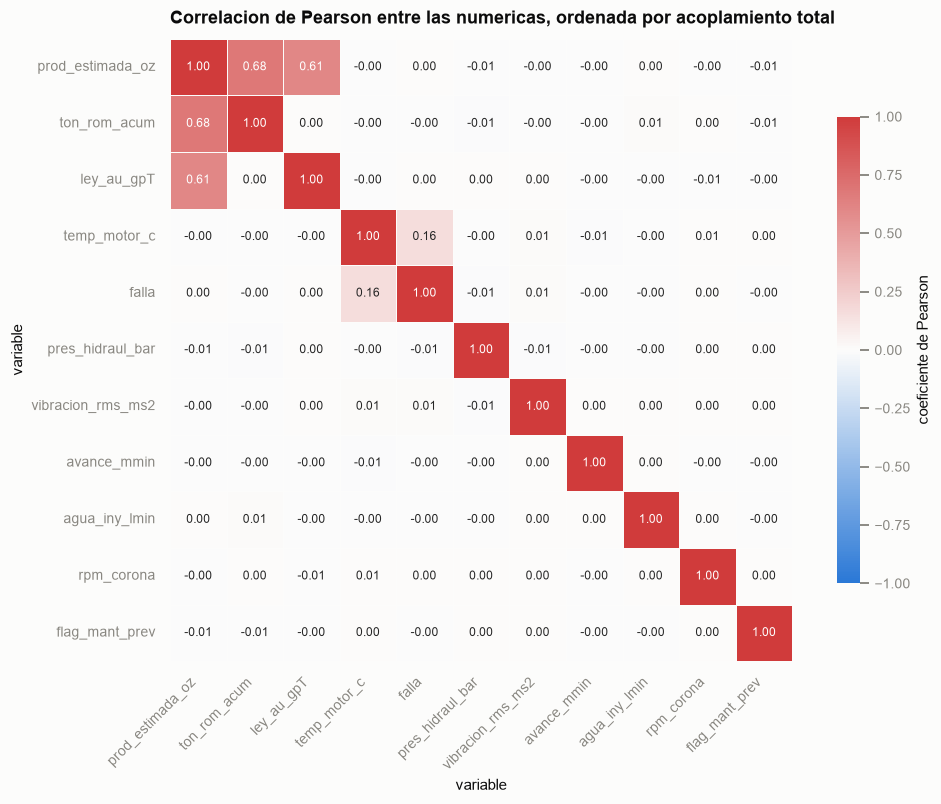

pares con |correlacion| > 0.10:
prod_estimada_oz  ton_rom_acum    0.682
                  ley_au_gpT      0.609
temp_motor_c      falla           0.160


In [9]:
# Correlacion lineal entre las numericas, sobre los registros con lectura valida de ley.
# Se ordena por suma de correlaciones absolutas para que las variables acopladas queden juntas.
NUMERICAS = ["ley_au_gpT", "prod_estimada_oz", "ton_rom_acum", *Extracto.SENSORES,
             "flag_mant_prev", "falla"]
corr_pearson = valida[NUMERICAS].astype(float).corr(method="pearson")
orden_corr = (corr_pearson.abs().sum() - 1).sort_values(ascending=False).index
corr_pearson = corr_pearson.loc[orden_corr, orden_corr]

graficos.matriz_correlacion(
    corr_pearson,
    "Correlacion de Pearson entre las numericas, ordenada por acoplamiento total",
    "coeficiente de Pearson")

triangulo = np.triu(np.ones(corr_pearson.shape), k=1).astype(bool)
pares_pearson = corr_pearson.where(triangulo).stack()
pares_pearson = pares_pearson[pares_pearson.abs() > 0.10].sort_values(key=abs, ascending=False)
print("pares con |correlacion| > 0.10:")
print(pares_pearson.round(3).to_string() if len(pares_pearson) else "  ninguno")

La matriz cierra la lectura de completitud con la de acoplamiento, y es casi toda blanca. Solo
tres pares pasan de 0.10 en valor absoluto:

- `prod_estimada_oz` con `ton_rom_acum` (0.68) y con `ley_au_gpT` (0.61), que son los dos
  factores de la relacion funcional que reconstruye la seccion 9.
- `temp_motor_c` con `falla` (0.16), un valor bajo para lo que en realidad es la senal mas
  fuerte del extracto: la tasa de falla pasa de 3.3% a 22% sobre los 95 C (seccion 15). La
  correlacion de Pearson mide relacion lineal y subestima una relacion de umbral, asi que esta
  matriz sirve para descartar redundancia, no para descartar variables.

Entre los sensores no hay ningun par acoplado: ninguno mide lo mismo que otro, no hay columnas
redundantes que eliminar, y ninguno se relaciona linealmente con la ley.

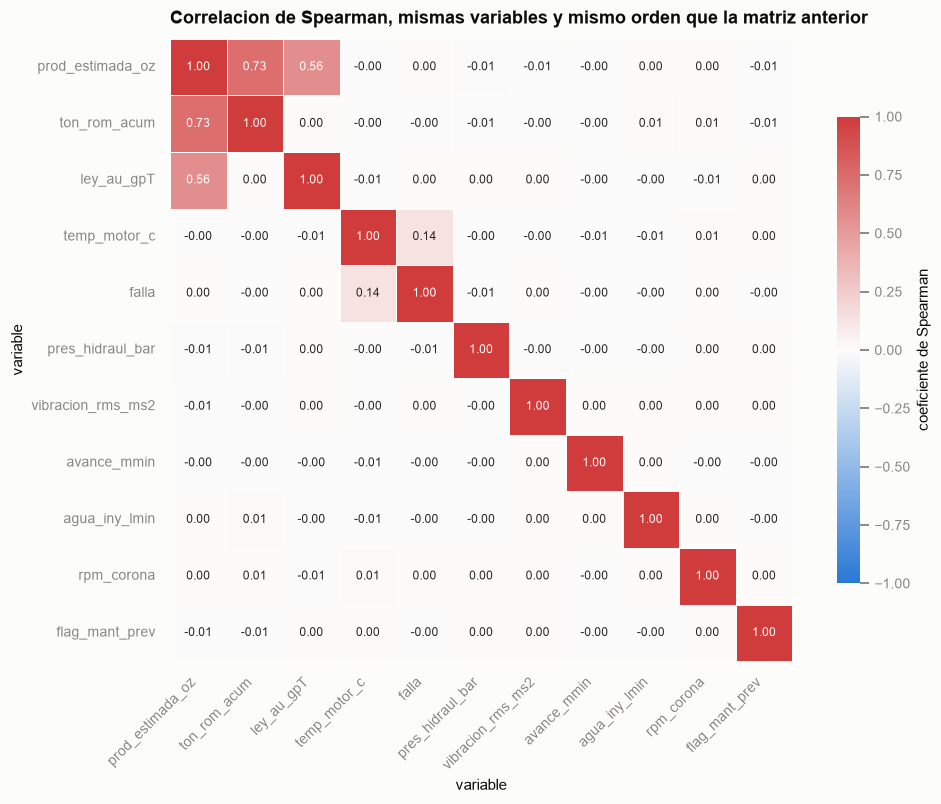

pares con |spearman| > 0.10:
                               pearson  spearman  gana_spearman
prod_estimada_oz ton_rom_acum    0.682     0.729          0.047
                 ley_au_gpT      0.609     0.563         -0.045
temp_motor_c     falla           0.160     0.137         -0.023

mayores diferencias a favor de Spearman (relacion monotona no lineal):
                                    pearson  spearman  gana_spearman
prod_estimada_oz ton_rom_acum         0.682     0.729          0.047
                 vibracion_rms_ms2   -0.002    -0.006          0.005
                 pres_hidraul_bar    -0.007    -0.010          0.003
temp_motor_c     agua_iny_lmin       -0.004    -0.007          0.003
ley_au_gpT       falla                0.002     0.004          0.002


In [10]:
# Spearman sobre las mismas variables y en el mismo orden, para comparar celda a celda.
# Pearson mide relacion lineal; Spearman, cualquier relacion monotona.
corr_spearman = valida[NUMERICAS].astype(float).corr(method="spearman").loc[orden_corr, orden_corr]

graficos.matriz_correlacion(
    corr_spearman,
    "Correlacion de Spearman, mismas variables y mismo orden que la matriz anterior",
    "coeficiente de Spearman")

comparacion_corr = pd.DataFrame({
    "pearson": corr_pearson.where(triangulo).stack(),
    "spearman": corr_spearman.where(triangulo).stack(),
})
comparacion_corr["gana_spearman"] = comparacion_corr["spearman"].abs() - comparacion_corr["pearson"].abs()
print("pares con |spearman| > 0.10:")
print(comparacion_corr[comparacion_corr["spearman"].abs() > 0.10]
      .sort_values("spearman", key=abs, ascending=False).round(3).to_string())
print()
print("mayores diferencias a favor de Spearman (relacion monotona no lineal):")
print(comparacion_corr.sort_values("gana_spearman", ascending=False).head(5).round(3).to_string())

Spearman no descubre ninguna relacion que Pearson hubiera ocultado: los mismos tres pares
superan 0.10, ningun otro se acerca, y la mayor ganancia de Spearman en todo el triangulo es de
0.047. Los cambios que aparecen confirman lo que ya se sabia de cada variable en lugar de
agregar algo nuevo:

- `prod_estimada_oz` con `ton_rom_acum` sube de 0.68 a 0.73 y con `ley_au_gpT` baja de 0.61 a
  0.56. Es lo esperable en un producto de dos factores mas un tercero categorico: la relacion
  con cada factor es monotona a factor fijo, pero el otro la escala y el orden global se
  mezcla. Ni Pearson ni Spearman la reproducen; la seccion 9 la recupera exacta despejando la
  formula.
- `temp_motor_c` con `falla` baja levemente, de 0.16 a 0.14. Es la confirmacion de que la
  relacion no es monotona gradual sino de umbral: por debajo de 95 C la temperatura casi no
  mueve la tasa de falla, y por encima la multiplica por siete. Ningun coeficiente de
  correlacion, lineal o de rangos, representa bien eso; hay que verlo por tasas condicionales,
  como en la seccion 15.

Conclusion de las dos matrices juntas: fuera de la dependencia funcional de
`prod_estimada_oz`, en este extracto no hay pares de variables que se muevan juntas, ni de
forma lineal ni monotona.

<a id="ts_opus_utc"></a>

## 2. `ts_opus_utc` — marca de tiempo del evento

Timestamp en UTC, unico por registro. Define el orden de todo el extracto y es el origen del
que se derivan el turno y la fecha local.

El archivo es un flujo de eventos ordenado en el tiempo. Antes de mirar el ritmo de cada
frente conviene mirar el del extracto completo, que es lo que revela como fue generado.

In [11]:
# Cadencia del extracto completo, sin separar por frente: un evento y el siguiente, sea cual
# sea el frente, el equipo o el operador.
cadencia = extracto.cadencia_global()

print("Frecuencia de muestreo global (minutos entre eventos consecutivos del archivo)")
print(cadencia.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2).to_string())
print()
frecuencia = cadencia.value_counts().sort_index()
print(pd.DataFrame({"minutos": frecuencia.index.astype(int),
                    "pares": frecuencia.to_numpy(),
                    "pct": (frecuencia.to_numpy() / len(cadencia) * 100).round(2)}).to_string(index=False))

Frecuencia de muestreo global (minutos entre eventos consecutivos del archivo)
count    49999.00
mean        24.49
std          5.77
min         15.00
1%          15.00
25%         19.00
50%         25.00
75%         29.00
95%         34.00
99%         34.00
max         34.00

 minutos  pares  pct
      15   2540 5.08
      16   2434 4.87
      17   2552 5.10
      18   2498 5.00
      19   2556 5.11
      20   2499 5.00
      21   2533 5.07
      22   2373 4.75
      23   2539 5.08
      24   2446 4.89
      25   2565 5.13
      26   2436 4.87
      27   2547 5.09
      28   2504 5.01
      29   2518 5.04
      30   2546 5.09
      31   2492 4.98
      32   2410 4.82
      33   2463 4.93
      34   2548 5.10


In [12]:
# Pruebas de simultaneidad: si diez equipos perforaran en paralelo, tendrian que solaparse.
por_ts = df.groupby("ts_opus_utc")
pruebas = pd.DataFrame([
    {"prueba": "timestamps duplicados",
     "observado": int(df["ts_opus_utc"].duplicated().sum()), "esperado_si_hay_paralelismo": "> 0"},
    {"prueba": "eventos en el mismo minuto calendario (max)",
     "observado": int(df.groupby(df["ts_opus_utc"].dt.floor("min")).size().max()), "esperado_si_hay_paralelismo": "> 1"},
    {"prueba": "frentes distintos en el mismo instante (max)",
     "observado": int(por_ts["frente_id"].nunique().max()), "esperado_si_hay_paralelismo": "> 1"},
    {"prueba": "equipos distintos en el mismo instante (max)",
     "observado": int(por_ts["equipo_id"].nunique().max()), "esperado_si_hay_paralelismo": "> 1"},
    {"prueba": "registros con segundos distintos de 00",
     "observado": int((df["ts_opus_utc"].dt.second != 0).sum()), "esperado_si_hay_paralelismo": "> 0"},
])
print(pruebas.to_string(index=False))
print()
print("eventos por dia calendario:")
print(df.groupby(df["ts_opus_utc"].dt.date).size().describe().round(2).to_string())
print()
por_turno = (df.assign(fecha_local=(df["ts_opus_utc"] - pd.Timedelta(hours=5)).dt.date)
               .groupby(["fecha_local", "turno_cod"]))
print("por turno-fecha: equipos distintos (media)", round(por_turno["equipo_id"].nunique().mean(), 2),
      "| frentes distintos (mediana)", int(por_turno["frente_id"].nunique().median()),
      "| registros (media)", round(por_turno.size().mean(), 1))

                                      prueba  observado esperado_si_hay_paralelismo
                       timestamps duplicados          0                         > 0
 eventos en el mismo minuto calendario (max)          1                         > 1
frentes distintos en el mismo instante (max)          1                         > 1
equipos distintos en el mismo instante (max)          1                         > 1
      registros con segundos distintos de 00          0                         > 0

eventos por dia calendario:
count    851.00
mean      58.75
std        2.31
min       20.00
25%       58.00
50%       59.00
75%       60.00
max       66.00

por turno-fecha: equipos distintos (media) 7.85 | frentes distintos (mediana) 1 | registros (media) 14.7


La cadencia global es **uniforme discreta entre 15 y 34 minutos**: cada valor entero de ese
rango aparece en cerca del 5% de los pares, nunca menos de 15 ni mas de 34, y todos los
timestamps caen en el segundo 00. Un proceso fisico de perforacion no produce una distribucion
plana y acotada asi; un generador que sortea el siguiente instante en un rango fijo, si.

Las pruebas de simultaneidad lo confirman por otro lado: **el extracto no tiene un solo evento
simultaneo**. Cero timestamps repetidos, nunca dos registros en el mismo minuto, jamas dos
frentes ni dos equipos a la vez. Con diez equipos y trece frentes eso es imposible en una
operacion real: diez perforadoras trabajando en paralelo se solapan en el tiempo por
construccion. El detalle que lo remata es que en un mismo turno y fecha aparecen en promedio
7.85 equipos distintos sobre un solo frente (mediana) en unos 15 registros: ocho perforadoras
rotando en el mismo frente durante seis horas, nunca a la vez.

### Supuesto adoptado

Ante dos lecturas posibles — que el extracto describa una sola maquina real o que sea un
extracto sintetico con las etiquetas repartidas al azar sobre un flujo unico — **se adopta la
segunda**, porque es la unica que explica todo lo observado a la vez: la cadencia uniforme y
acotada, los segundos siempre en 00, la ausencia total de simultaneidad, y lo que se vera en
las secciones 18 y 19 — cada equipo aparece en los trece frentes, cada operador en los diez
equipos, y las leyes medias y las tasas de falla son planas entre unos y otros. La lectura de
"una sola maquina" explicaria la serializacion pero no la uniformidad de la cadencia ni el
reparto perfecto de etiquetas.

El supuesto se enuncia como supuesto, no como hecho sobre la unidad minera: lo demostrado es
que el archivo es un flujo estrictamente serial de unos 59 eventos por dia y que `equipo_id`
no puede representar diez perforadoras operando en paralelo.

**Que implica adoptarlo.** `equipo_id` y `op_id` quedan fuera de toda lectura causal: no se
concluye nada sobre el desempeno de una maquina ni de una cuadrilla, y buscarles senal es
perseguir ruido. El orden temporal del archivo es orden de emision, no secuencia de operacion
concurrente, de modo que no tiene sentido preguntarse que ocurria en la mina en un instante
dado. Nada de esto alcanza a `ley_au_gpT`, `frente_id` ni `sector_geol`: su estructura interna
es consistente — jerarquia limpia, separacion de 12.4 g/t entre frentes, centinela con un
patron claro por turno — y ahi esta la senal aprovechable del extracto.

**Advertencia, no bloqueo.** Las implicaciones causales anteriores pueden dejarse de lado
deliberadamente para continuar con el trabajo: si lo que se pide es tratar `equipo_id` y
`op_id` como cualquier otra variable, se hace, y el resultado sera tecnicamente correcto
aunque no signifique nada sobre maquinas ni operadores. Lo que no puede pasar es que la
advertencia se pierda: queda registrada aqui para que cualquier conclusion que se apoye en
esas dos columnas se lea sabiendo que describe la construccion del archivo y no la operacion
minera.

In [13]:
ts = df["ts_opus_utc"]
span_meses = (ts.max() - ts.min()).days / 30.44
print(f"inicio : {ts.min()}")
print(f"fin    : {ts.max()}")
print(f"span   : {span_meses:.1f} meses  (el enunciado describe 18)")

huecos = extracto.cadencia_por_frente()
print()
print("intervalo entre eventos del mismo frente (minutos):")
print(huecos.describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(1).to_string())
print()
print("huecos de mas de 7 dias dentro de un frente:", int((huecos > 7 * 1440).sum()))
actividad = extracto.actividad_por_frente_y_mes()
meses_vacios = (actividad == 0).sum(axis=1)
print(f"meses sin registros por frente: de {meses_vacios.min()} a {meses_vacios.max()}"
      f" sobre {actividad.shape[1]} meses cubiertos")

inicio : 2023-07-01 00:16:00
fin    : 2025-10-28 07:59:00
span   : 27.9 meses  (el enunciado describe 18)

intervalo entre eventos del mismo frente (minutos):
count     49987.0
mean        307.9
std        3407.9
min          15.0
25%          20.0
50%          25.0
75%          30.0
95%          34.0
max      166274.0

huecos de mas de 7 dias dentro de un frente: 422
meses sin registros por frente: de 2 a 6 sobre 28 meses cubiertos


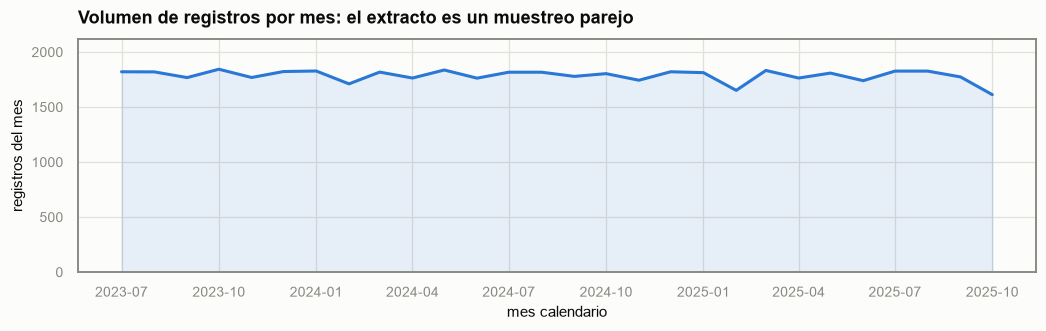

In [14]:
por_mes = df.set_index("ts_opus_utc").resample("MS").size()
graficos.serie_temporal(por_mes.index, por_mes.to_numpy(),
                        "Volumen de registros por mes: el extracto es un muestreo parejo",
                        "mes calendario", "registros del mes")

**Que es un "par".** Las dos figuras que siguen no cuentan registros sino **pares de eventos
consecutivos dentro de un mismo frente**: se ordena el extracto por tiempo, se agrupa por
`frente_id` y se toma la diferencia entre cada evento y el anterior *de ese frente*. El primer
evento de cada frente no tiene anterior, asi que quedan 50000 - 13 = **49987 pares**, cada uno
con una duracion en minutos. Sin separar por frente se obtiene otra cosa: la cadencia global del
archivo, que es la que ya se midio al comienzo de esta seccion.

**Como leer los dos paneles.**

- *Izquierda*: solo los pares de hasta 60 minutos, que son el 98.65% del total, con un bin por
  minuto. La distribucion es plana entre 15 y 34 minutos y **no hay ningun par por debajo de
  15**, exactamente el mismo piso y el mismo techo que la cadencia global: dentro de un frente
  activo, el archivo emite eventos con el mismo intervalo con que los emite en conjunto.
- *Derecha*: los 49987 pares, ahora en dias y en escala logaritmica, que es la unica forma de
  ver a la vez un intervalo de 20 minutos y uno de 115 dias. La caja va de 0.014 a 0.021 dias
  (20 a 30 minutos) y por eso aparece como una franja finisima a la izquierda: la mitad central
  de los datos ocupa diez minutos de ancho. La nube de puntos que se extiende a la derecha son
  los valores atipicos del criterio de Tukey, 675 pares por encima de 45 minutos, y ahi estan
  las 635 pausas de mas de un dia.

Los dos paneles miden lo mismo y cuentan cosas opuestas. Esa es la razon de ponerlos juntos: la
variable no tiene un solo comportamiento, tiene dos regimenes.

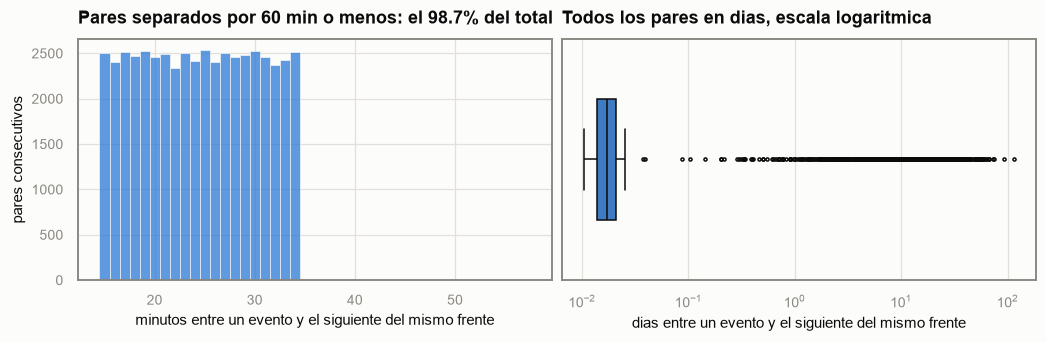

In [15]:
cortos = huecos[huecos <= 60]
graficos.paneles_intervalo(cortos, huecos / 1440)

El contraste entre los dos paneles anticipa el problema de resumir esta variable con un solo
numero. La descomposicion siguiente lo cuantifica.

In [16]:
# Que desplaza la media de 25 a 308 minutos: descomposicion del tiempo por tramo de hueco.
TRAMOS: list[tuple[float, float, str]] = [
    (0, 60, "hasta 1 h"), (60, 1440, "1 h a 1 dia"),
    (1440, 10080, "1 a 7 dias"), (10080, float("inf"), "mas de 7 dias"),
]

descomposicion = pd.DataFrame([
    {"tramo": etiqueta,
     "pares": int(((huecos > lo) & (huecos <= hi)).sum()),
     "pct_pares": round(((huecos > lo) & (huecos <= hi)).mean() * 100, 2),
     "aporte_a_la_media_min": round(huecos[(huecos > lo) & (huecos <= hi)].sum() / len(huecos), 1),
     "pct_del_tiempo": round(huecos[(huecos > lo) & (huecos <= hi)].sum() / huecos.sum() * 100, 1)}
    for lo, hi, etiqueta in TRAMOS
])
print(descomposicion.to_string(index=False))
print()
print(f"media = {huecos.mean():.1f} min | mediana = {huecos.median():.0f} min")

pausas = df.loc[huecos[huecos > 1440].index].assign(dias=huecos[huecos > 1440] / 1440)
print()
print("pausas de mas de un dia:", len(pausas))
print(pausas["dias"].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(1).to_string())
print()
print("pausas por frente:", pausas["frente_id"].value_counts().min(), "a",
      pausas["frente_id"].value_counts().max(), "cada uno")
print("pausas por mes de reinicio:", pausas["ts_opus_utc"].dt.to_period("M").value_counts().min(),
      "a", pausas["ts_opus_utc"].dt.to_period("M").value_counts().max())
print()
print(f"hueco maximo del extracto completo, sin separar por frente: {cadencia.max():.0f} min")

        tramo  pares  pct_pares  aporte_a_la_media_min  pct_del_tiempo
    hasta 1 h  49314      98.65                   24.2             7.8
  1 h a 1 dia     38       0.08                    0.6             0.2
   1 a 7 dias    213       0.43                   24.0             7.8
mas de 7 dias    422       0.84                  259.2            84.2

media = 307.9 min | mediana = 25 min

pausas de mas de un dia: 635
count    635.0
mean      15.5
std       14.3
min        1.0
25%        5.4
50%       10.8
75%       21.0
95%       43.4
max      115.5

pausas por frente: 40 a 60 cada uno
pausas por mes de reinicio: 11 a 34

hueco maximo del extracto completo, sin separar por frente: 34 min


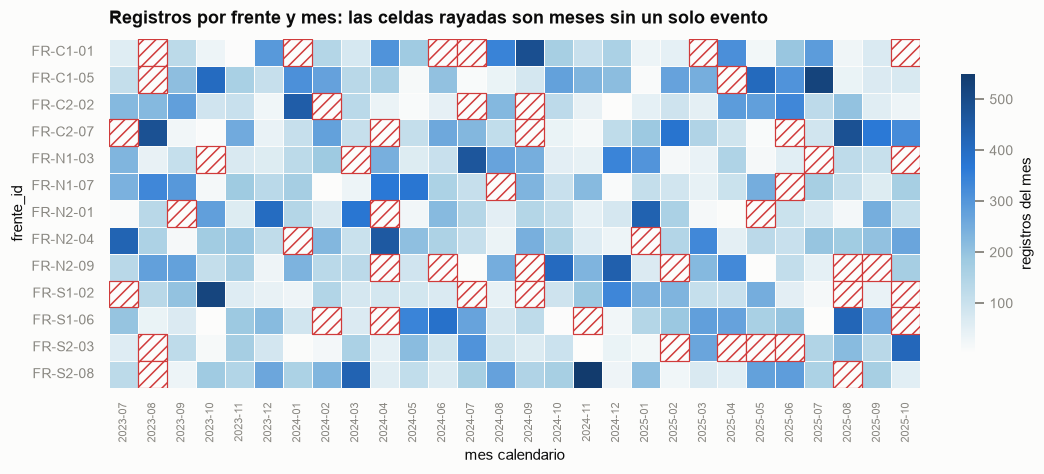

In [17]:
graficos.mapa_calor_actividad(
    actividad,
    "Registros por frente y mes: las celdas rayadas son meses sin un solo evento")

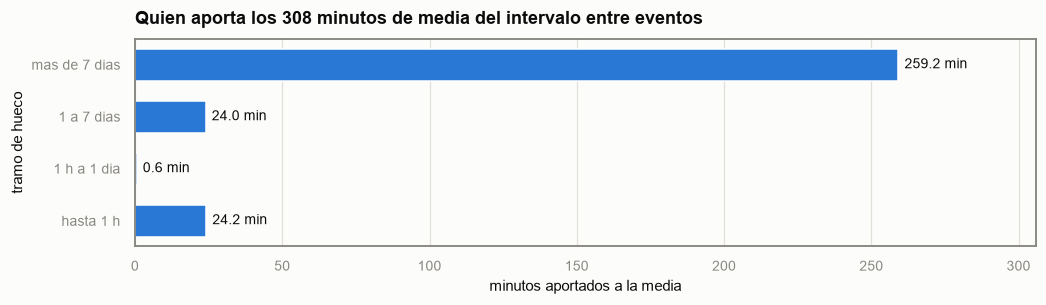

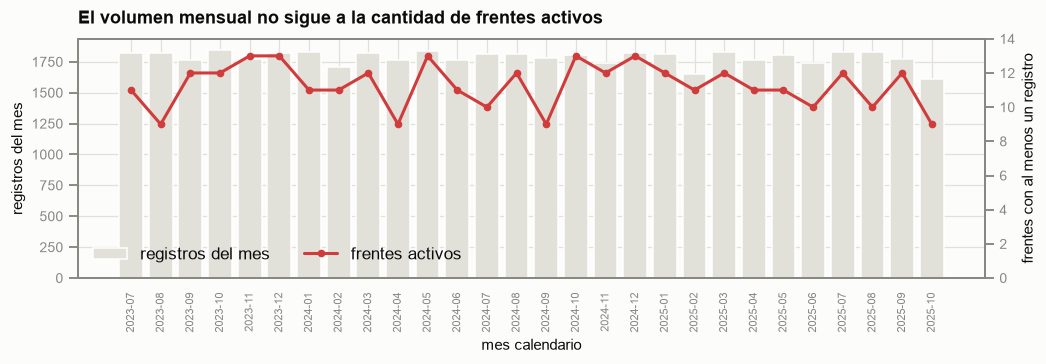

In [18]:
graficos.barras_horizontales(
    descomposicion["tramo"].to_list(), descomposicion["aporte_a_la_media_min"].to_list(),
    "Quien aporta los 308 minutos de media del intervalo entre eventos",
    "minutos aportados a la media", "tramo de hueco", formato="{:.1f} min")

frentes_activos = (actividad > 0).sum(axis=0)
registros_mes = actividad.sum(axis=0)
graficos.volumen_y_frentes([str(m) for m in actividad.columns], registros_mes.to_numpy(),
                           frentes_activos.to_numpy(), df["frente_id"].nunique())

**Que desplaza la media.** El 98.7% de los pares consecutivos esta separado por una hora o
menos y aporta 24 de los 308 minutos de media: ese es el intervalo con que el archivo emite
eventos de un frente activo. Los 308 minutos los pone el 0.84% de pares separados por mas de
siete dias, que concentra el **84% del tiempo transcurrido** del extracto. Entre una hora y un
dia casi no hay nada: 38 pares en cincuenta mil. La distribucion no es de cola larga, es
**bimodal** — o el frente emite cada 25 minutos, o desaparece del archivo por semanas, sin
termino medio.

Esas pausas largas son 635, con mediana de 10.8 dias y maximo de 115, y estan repartidas de
forma uniforme: entre 40 y 60 por frente, entre 11 y 34 por mes de reinicio, sin concentrarse en
ningun frente ni en ningun periodo del calendario. Lo que se puede afirmar es que las pausas son
de la etiqueta `frente_id`, no del archivo: **el extracto completo, sin separar por frente, nunca
tiene un hueco de mas de 34 minutos**, y en cualquier mes aparecen entre 9 y 13 frentes mientras
el volumen mensual se mantiene entre 1613 y 1844 registros. El flujo de eventos es continuo y lo
que alterna es a que frente se asigna cada uno. Bajo el supuesto de la seccion 2 esto describe
como se construyo el archivo, no una decision operativa de mover cuadrillas.

Para leer la variable: la media del intervalo entre eventos de un frente no describe nada,
porque mezcla dos regimenes distintos. La cadencia esta en la mediana, 25 minutos; la
intermitencia de la etiqueta esta en la cuenta de pausas, y son dos cosas que hay que mirar por
separado.

El extracto va del 2023-07-01 al 2025-10-28: **27.9 meses**, no los 18 que describe el
enunciado. El intervalo dentro de un frente activo es de 25 minutos (mediana), con un cuartil
superior de 30, pero la media de 308 minutos revela que los frentes no aparecen de forma
continua: 422 huecos superan la semana y cada frente pasa entre dos y seis meses sin un solo
registro. El mapa de calor lo muestra de frente: las celdas rayadas son meses en los que un
frente no registro un solo evento, y ninguna columna las tiene todas, de modo que la
intermitencia esta escalonada entre frentes y nunca deja el archivo vacio.

El volumen mensual del extracto completo, en cambio, es plano: el escalonamiento no cambia el
ritmo agregado, y no hay estacionalidad, huecos de meses completos ni un tramo inicial de
arranque que descartar.

<a id="turno_cod"></a>

## 3. `turno_cod` — turno operacional

Cuatro categorias (D1, D2, N1, N2) repartidas casi por igual, unas 12500 filas cada una. El
diccionario no dice como se asigna el turno ni en que zona horaria opera la unidad; el cruce
con la hora del timestamp responde las dos preguntas.

In [19]:
turno_hora = pd.crosstab(df["ts_opus_utc"].dt.hour, df["turno_cod"])
turno_hora = turno_hora[["D1", "D2", "N1", "N2"]]
print("Horas UTC cubiertas por cada turno:")
for turno in turno_hora.columns:
    horas = sorted(turno_hora.index[turno_hora[turno] > 0].tolist())
    print(f"  {turno}: {horas}")
print()
print("filas donde la hora UTC no determina el turno:",
      int((turno_hora.gt(0).sum(axis=1) > 1).sum()))

Horas UTC cubiertas por cada turno:
  D1: [11, 12, 13, 14, 15, 16]
  D2: [17, 18, 19, 20, 21, 22]
  N1: [0, 1, 2, 3, 4, 23]
  N2: [5, 6, 7, 8, 9, 10]

filas donde la hora UTC no determina el turno: 0


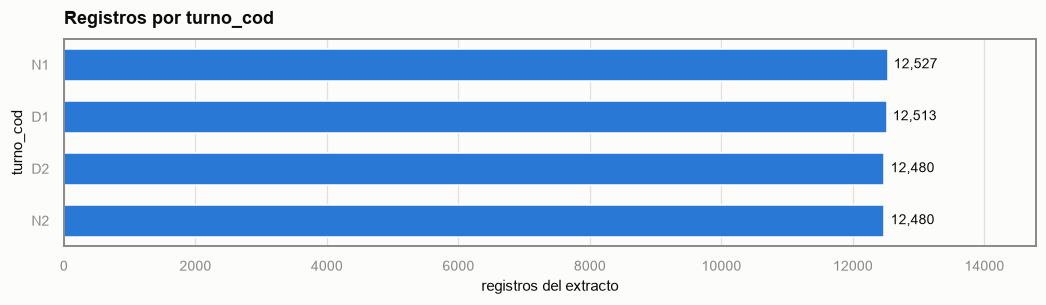

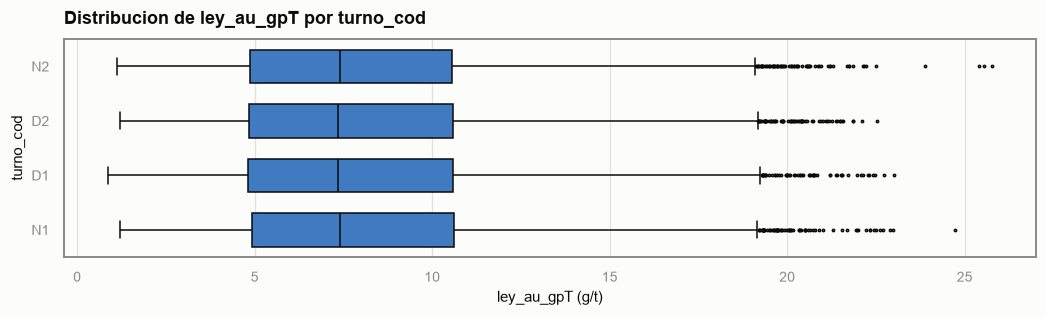

,registros,ley_media,falla_pct
turno_cod,,,
N1,12527,8.02,3.31
D1,12513,7.99,3.28
D2,12480,7.99,3.37
N2,12480,7.99,3.31


In [20]:
tabla_turno = analisis.perfil_categorica("turno_cod")
display(tabla_turno)

Cada hora UTC pertenece a un unico turno, con fronteras en 05:00, 11:00, 17:00 y 23:00 UTC:
`turno_cod` es una funcion determinista de `ts_opus_utc` y no aporta informacion independiente.
Restando cinco horas se obtienen turnos de seis horas que empiezan a las 00:00, 06:00, 12:00 y
18:00, y en ese calendario el orden cronologico del dia es N2, D1, D2, N1. Lo demostrable es
que **el desfase implicito del archivo es de cinco horas**; que corresponda a la zona horaria de
la operacion es la interpretacion natural, pero el archivo no declara zona horaria en ninguna
parte y no hay con que verificarlo.

<a id="frente_id"></a>

## 4. `frente_id` — frente de trabajo

Trece frentes identificados con el patron `FR-<zona><n>-<nn>`. Es la variable de ubicacion mas
fina del extracto.

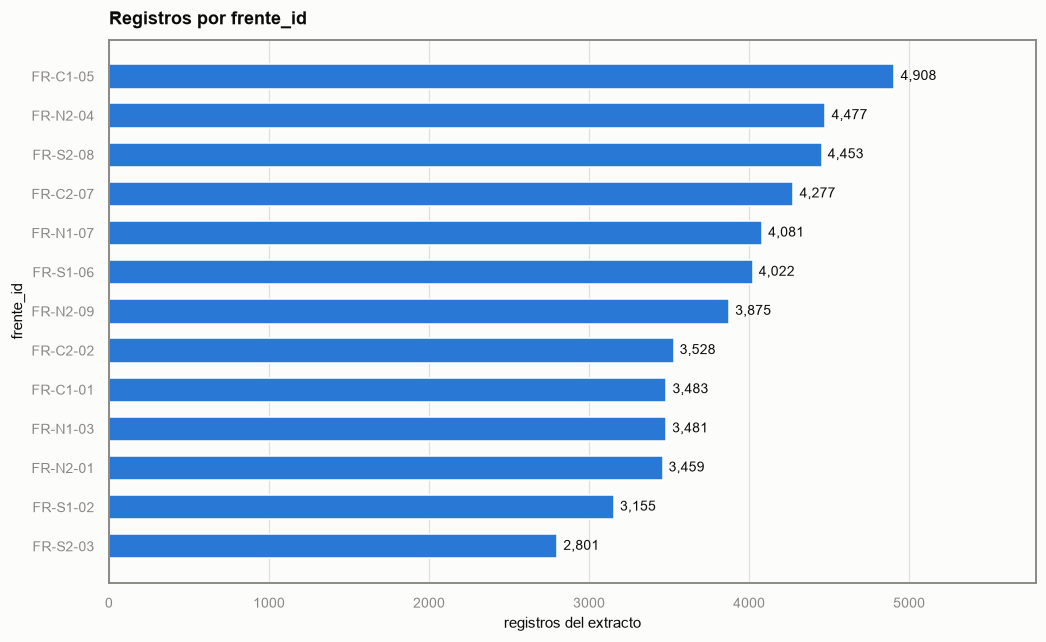

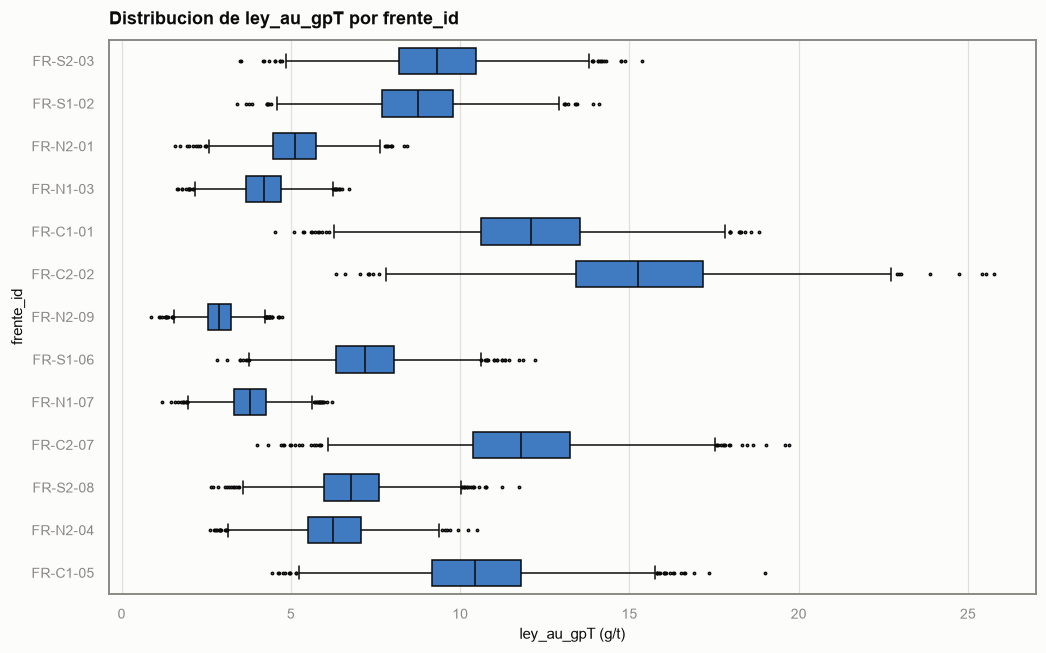

,registros,ley_media,falla_pct
frente_id,,,
FR-C1-05,4908,10.48,3.38
FR-N2-04,4477,6.28,3.40
FR-S2-08,4453,6.79,3.19
FR-C2-07,4277,11.81,3.23
FR-N1-07,4081,3.80,2.94
FR-S1-06,4022,7.19,3.18
FR-N2-09,3875,2.89,2.92
FR-C2-02,3528,15.30,3.34
FR-C1-01,3483,12.10,3.53


In [21]:
tabla_frente = analisis.perfil_categorica("frente_id")
display(tabla_frente)

In [22]:
por_frente = valida.groupby("frente_id")["ley_au_gpT"].mean().sort_values()
print(f"ley media por frente: {por_frente.min():.2f} a {por_frente.max():.2f} g/t "
      f"(amplitud {por_frente.max() - por_frente.min():.2f})")

ley media por frente: 2.89 a 15.30 g/t (amplitud 12.41)


El frente es la variable que mas separa la ley de todo el extracto: la media va de 2.9 a
15.3 g/t, cinco veces entre el frente mas pobre y el mas rico. La tasa de falla, en cambio, es
practicamente la misma en todos (entre 2.9% y 3.9%). En el archivo, `frente_id` organiza la ley
y no organiza nada de la maquina.

In [23]:
# Cuanta de la ley explica el frente, y que queda despues de descontarlo.
media_por_frente = valida.groupby("frente_id")["ley_au_gpT"].transform("mean")
suma_total = ((valida["ley_au_gpT"] - valida["ley_au_gpT"].mean()) ** 2).sum()
for etiqueta, agrupacion in [("frente_id", ["frente_id"]),
                             ("frente_id x tipo_mineral", ["frente_id", "tipo_mineral"]),
                             ("sector_geol", ["sector_geol"])]:
    ajuste = valida.groupby(agrupacion)["ley_au_gpT"].transform("mean")
    residuo = ((valida["ley_au_gpT"] - ajuste) ** 2).sum()
    print(f"R2 de un modelo que solo usa la media de {etiqueta:24s}: {1 - residuo / suma_total:.4f}")

# Autocorrelacion: primero cruda, despues descontando el nivel del frente.
orden_temporal = df.sort_values("ts_opus_utc")
ley_valida = orden_temporal["ley_au_gpT"].mask(orden_temporal["ley_sentinela"])
anterior = ley_valida.groupby(orden_temporal["frente_id"], sort=False).shift(1)
nivel = ley_valida.groupby(orden_temporal["frente_id"], sort=False).transform("mean")
print()
print(f"corr(ley, lectura anterior del mismo frente)        : {ley_valida.corr(anterior):+.4f}")
print(f"corr de los residuos, descontada la media del frente: "
      f"{(ley_valida - nivel).corr(anterior - nivel):+.4f}")

R2 de un modelo que solo usa la media de frente_id               : 0.8316
R2 de un modelo que solo usa la media de frente_id x tipo_mineral: 0.8317
R2 de un modelo que solo usa la media de sector_geol             : 0.7343

corr(ley, lectura anterior del mismo frente)        : +0.8295
corr de los residuos, descontada la media del frente: -0.0010


In [24]:
# El objetivo real del modelado es la ley media del turno siguiente en el mismo frente.
por_turno = (valida.groupby(["frente_id", "fecha_local", "turno_cod"])
                   .agg(ley_turno=("ley_au_gpT", "mean"), cierre=("ts_opus_utc", "max"))
                   .reset_index().sort_values(["frente_id", "cierre"]))
por_turno["ley_siguiente"] = por_turno.groupby("frente_id")["ley_turno"].shift(-1)
comparables = por_turno.dropna(subset=["ley_siguiente"])
nivel_frente = comparables.groupby("frente_id")["ley_turno"].transform("mean")

suma_total = ((comparables["ley_siguiente"] - comparables["ley_siguiente"].mean()) ** 2).sum()
print(f"turnos con turno siguiente en el mismo frente: {len(comparables):,}")
for etiqueta, prediccion in [("la media historica del frente", nivel_frente),
                             ("la ley del turno anterior", comparables["ley_turno"])]:
    residuo = ((comparables["ley_siguiente"] - prediccion) ** 2).sum()
    print(f"  R2 prediciendo con {etiqueta:30s}: {1 - residuo / suma_total:.4f}")
print(f"  corr de los residuos entre turno actual y siguiente: "
      f"{(comparables['ley_turno'] - nivel_frente).corr(comparables['ley_siguiente'] - nivel_frente):+.4f}")

turnos con turno siguiente en el mismo frente: 3,995
  R2 prediciendo con la media historica del frente : 0.9752
  R2 prediciendo con la ley del turno anterior     : 0.9505
  corr de los residuos entre turno actual y siguiente: +0.0013


**La ley es el nivel del frente mas ruido blanco.** Un modelo que solo usa la media del frente
explica el **83%** de la varianza de la ley, y agregar el tipo de mineral no aporta una
milesima. La autocorrelacion aparente lo confirma desde el otro lado: una lectura correlaciona
0.83 con la anterior del mismo frente, pero al descontar la media de ese frente la correlacion
cae a **-0.001**. No hay memoria en el proceso, hay un nivel por frente y ruido alrededor.

Sobre el objetivo real —la ley media del turno siguiente— la conclusion se agudiza: la media
historica del frente predice con **R2 = 0.9752** y el turno anterior con 0.9505. El promedio
del frente le gana al ultimo dato, y los residuos de un turno no anticipan los del siguiente
(correlacion +0.001).

Dos consecuencias que hay que tener presentes al modelar: el baseline honesto no es "repetir el
ultimo valor" sino "la media del frente", y cualquier feature de historia de ley sera un
estimador mas ruidoso de ese mismo nivel, no informacion nueva.

<a id="sector_geol"></a>

## 5. `sector_geol` — sector geologico

Cuatro sectores. No es una variable independiente de `frente_id`: el prefijo de zona del codigo
de frente determina el sector.

frente_id      FR-C1-01 FR-C1-05 FR-C2-02 FR-C2-07 FR-N1-03 FR-N1-07 FR-N2-01 FR-N2-04 FR-N2-09 FR-S1-02 FR-S1-06 FR-S2-03 FR-S2-08
sector_geol                                                                                                                        
Cuerpo-Central     3483     4908                                                                                                   
Rampa-Norte                                            3481     4081     3459     4477     3875                                    
Veta-Principal                       3528     4277                                                                                 
Veta-Sur                                                                                            3155     4022     2801     4453

sectores distintos por frente: 1


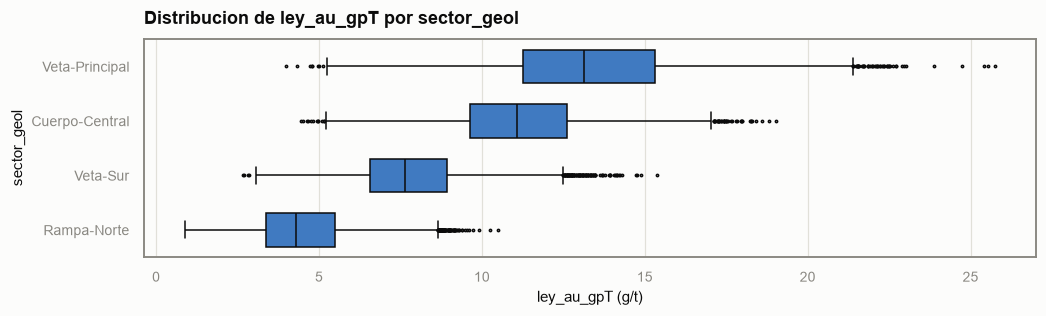

,registros,ley_media,falla_pct
sector_geol,,,
Rampa-Norte,19373,4.52,3.27
Veta-Sur,14431,7.82,3.33
Cuerpo-Central,8391,11.15,3.44
Veta-Principal,7805,13.38,3.28


In [25]:
print(pd.crosstab(df["sector_geol"], df["frente_id"]).replace(0, "").to_string())
print()
print("sectores distintos por frente:", int(df.groupby("frente_id")["sector_geol"].nunique().max()))

tabla_sector = analisis.perfil_categorica("sector_geol", conteo=False)
display(tabla_sector)

Cada frente pertenece a un unico sector: `frente_id` y `sector_geol` son la misma jerarquia a
dos granularidades, trece nodos contra cuatro. La ley media por sector va de 4.5 g/t en
Rampa-Norte a 13.4 g/t en Veta-Principal, un rango mas estrecho que el de frente porque agrega
frentes de leyes distintas dentro de un mismo sector.

<a id="tipo_mineral"></a>

## 6. `tipo_mineral` — tipo de mineral

Cuatro categorias: OX (oxido), SUL (sulfuro), MIX (mixto) y EST (esteril). Las tres primeras
reparten unos 14300 registros cada una y EST la mitad, 7140.

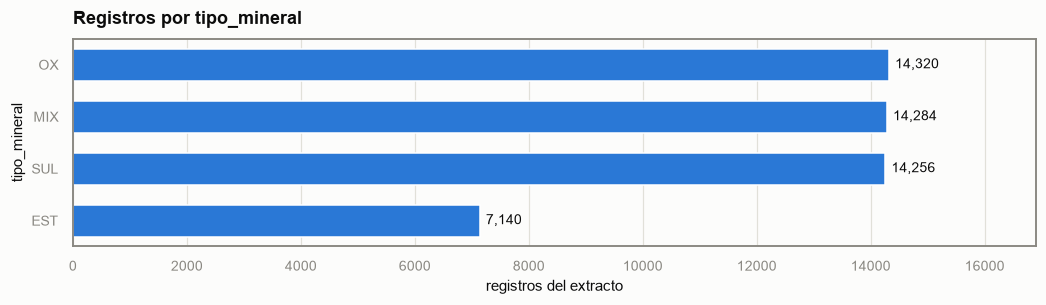

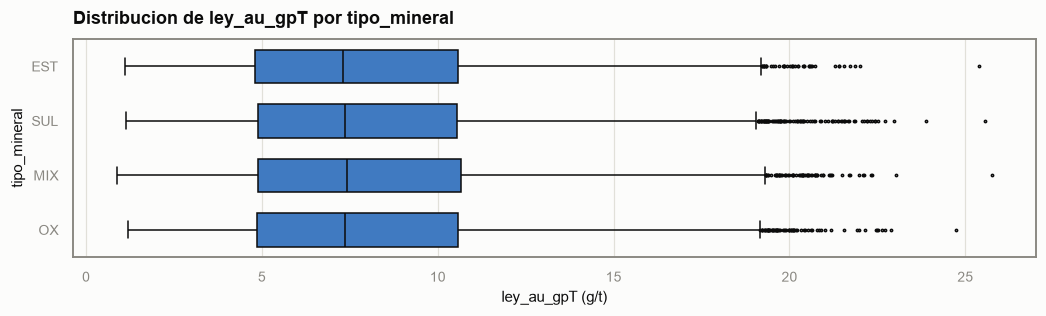

,registros,ley_media,falla_pct
tipo_mineral,,,
OX,14320,7.97,3.22
MIX,14284,8.03,3.51
SUL,14256,8.01,3.25
EST,7140,7.97,3.25


In [26]:
tabla_tipo = analisis.perfil_categorica("tipo_mineral")
display(tabla_tipo)

El tipo de mineral **no discrimina la ley**: las medias van de 7.97 a 8.03 g/t, un rango de
0.06 contra los 12.4 de `frente_id`. Es contraintuitivo desde el dominio y conviene declararlo:
en este extracto el tipo de mineral no describe cuanto oro hay sino como se recupera, y su
efecto aparece completo en `prod_estimada_oz` a traves del factor de recuperacion metalurgica
(seccion 9). Tampoco separa la tasa de falla.

<a id="ley_au_gpT"></a>

## 7. `ley_au_gpT` — ley de oro, el objetivo de regresion

Gramos de oro por tonelada medidos con sonda XRF. El enunciado advierte que "puede contener
valores especiales": no son nulos, estan codificados dentro del rango numerico.

In [27]:
ley = df["ley_au_gpT"]
print(ley.describe().round(4).to_string())
print()
print("valores negativos:", int((ley < 0).sum()), "| valores distintos negativos:", sorted(ley[ley < 0].unique()))
print("valores en cero  :", int((ley == 0).sum()))
print("nulos declarados :", int(ley.isna().sum()))

count    50000.0000
mean         7.4927
std          4.2761
min         -1.0000
25%          4.4118
50%          7.0836
75%         10.3580
max         25.7603

valores negativos: 2810 | valores distintos negativos: [np.float64(-1.0)]
valores en cero  : 0
nulos declarados : 0


El unico valor negativo es exactamente `-1.0`, en 2810 registros (5.6%). Una ley de oro negativa
no existe fisicamente: es el codigo de "sin lectura valida de la sonda". Cualquier estadistica
que lo incluya como si fuera una medicion queda contaminada. Descontados esos registros, la ley
va de 0.87 a 25.76 g/t con media de 8.0.

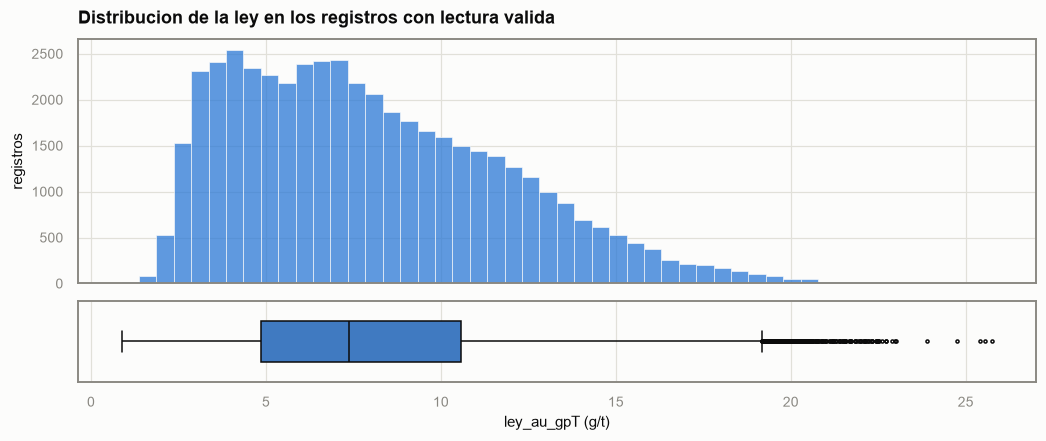

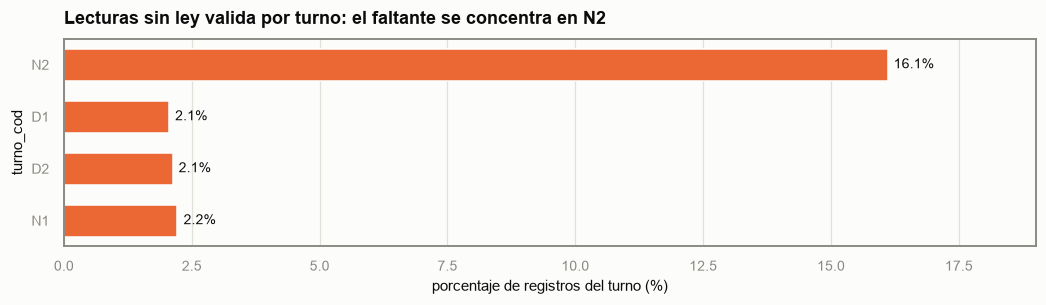

In [28]:
graficos.histograma_y_caja(valida["ley_au_gpT"],
                           "Distribucion de la ley en los registros con lectura valida",
                           "ley_au_gpT (g/t)")

tasa_sentinela = (df.groupby("turno_cod")["ley_sentinela"].mean().mul(100)
                    .reindex(["N1", "D2", "D1", "N2"]))
graficos.barras_horizontales(
    tasa_sentinela.index.to_list(), tasa_sentinela.to_numpy(),
    "Lecturas sin ley valida por turno: el faltante se concentra en N2",
    "porcentaje de registros del turno (%)", "turno_cod",
    formato="{:.1f}%", color=PALETA.series[1])

La ausencia de lectura **no es aleatoria**: el turno N2 concentra el 16.1% de sus registros sin
ley, frente a cerca del 2% en los otros tres. Es un faltante condicionado a una variable
observada, no un faltante completamente al azar, y por lo tanto los registros sin ley no son
intercambiables con el resto.

In [29]:
ventana = (df.assign(fecha=df["ts_opus_utc"].dt.floor("D"))
             .loc[~df["ley_sentinela"]]
             .groupby(["frente_id", "tipo_mineral"])
             .size())
print("registros con ley valida por combinacion frente x tipo_mineral:")
print(ventana.describe().round(1).to_string())
print()
print("combinaciones existentes:", len(ventana), "de", df["frente_id"].nunique() * df["tipo_mineral"].nunique(), "posibles")

registros con ley valida por combinacion frente x tipo_mineral:
count      52.0
mean      907.5
std       270.8
min       357.0
25%       731.8
50%       943.5
75%      1117.5
max      1359.0

combinaciones existentes: 52 de 52 posibles


In [30]:
comparacion = pd.DataFrame({
    "por sector_geol": valida.groupby("sector_geol")["ley_au_gpT"].mean().agg(["min", "max"]),
    "por frente_id": valida.groupby("frente_id")["ley_au_gpT"].mean().agg(["min", "max"]),
    "por tipo_mineral": valida.groupby("tipo_mineral")["ley_au_gpT"].mean().agg(["min", "max"]),
    "por turno_cod": valida.groupby("turno_cod")["ley_au_gpT"].mean().agg(["min", "max"]),
}).T
comparacion["rango"] = (comparacion["max"] - comparacion["min"]).round(2)
comparacion.round(2)

,min,max,rango
por sector_geol,4.52,13.38,8.87
por frente_id,2.89,15.30,12.41
por tipo_mineral,7.97,8.03,0.06
por turno_cod,7.99,8.02,0.04


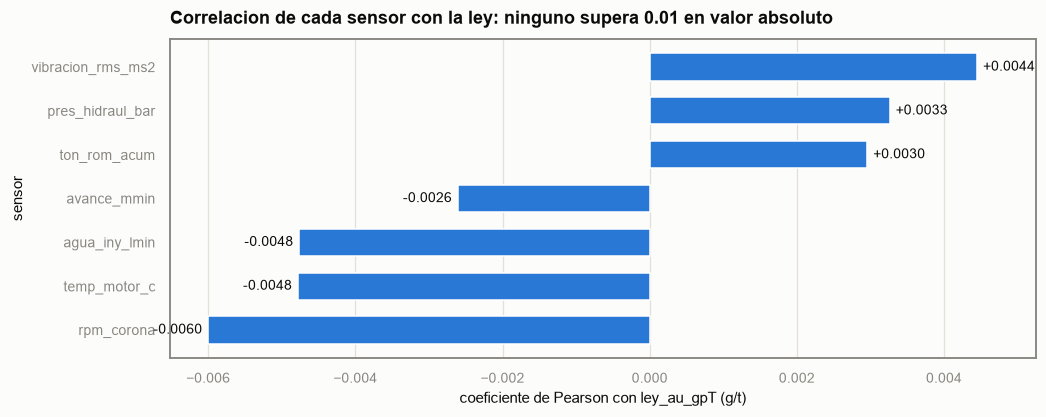

In [31]:
correlaciones = (valida[[*Extracto.SENSORES, "ton_rom_acum", "ley_au_gpT"]]
                 .corr()["ley_au_gpT"].drop("ley_au_gpT").sort_values())
graficos.barras_horizontales(
    correlaciones.index.to_list(), correlaciones.to_numpy(),
    "Correlacion de cada sensor con la ley: ninguno supera 0.01 en valor absoluto",
    "coeficiente de Pearson con ley_au_gpT (g/t)", "sensor", formato="{:+.4f}")

Que organiza la ley en este archivo: la ubicacion, no los sensores. Ninguno supera 0.01 de
correlacion con ella, mientras que agrupar por frente separa 12.4 g/t entre extremos y por
sector 8.9. Coincide con lo que dice el dominio — la ley es una propiedad del macizo rocoso y
los sensores describen como se perfora, no cuanto oro hay — pero lo que el dato demuestra es la
estructura del archivo, no la geologia de la unidad: la ley esta construida sobre la etiqueta de
frente y es independiente de las columnas de maquina.

El grupo natural para caracterizar una ley faltante a partir de sus vecinas es la combinacion
frente por tipo de mineral: existen las 52 combinaciones posibles y ninguna baja de varios
centenares de registros con lectura valida.

In [32]:
# La dispersion de la ley no es constante: crece con el nivel del frente.
por_frente = valida.groupby("frente_id")["ley_au_gpT"].agg(media="mean", desviacion="std")
por_frente["coef_variacion"] = (por_frente["desviacion"] / por_frente["media"]).round(3)
por_frente["asimetria"] = valida.groupby("frente_id")["ley_au_gpT"].skew()
print(por_frente.round(3).to_string())
print()
print(f"corr(media, desviacion) entre frentes: {por_frente['media'].corr(por_frente['desviacion']):.3f}")
print(f"coeficiente de variacion: de {por_frente['coef_variacion'].min():.3f} a "
      f"{por_frente['coef_variacion'].max():.3f}")
print(f"asimetria promedio dentro de un frente: {por_frente['asimetria'].mean():+.3f}")

            media  desviacion  coef_variacion  asimetria
frente_id                                               
FR-C1-01   12.104       2.179           0.180      0.017
FR-C1-05   10.480       1.924           0.184      0.076
FR-C2-02   15.300       2.760           0.180      0.032
FR-C2-07   11.811       2.121           0.180      0.000
FR-N1-03    4.182       0.758           0.181     -0.033
FR-N1-07    3.798       0.682           0.180      0.049
FR-N2-01    5.108       0.940           0.184     -0.053
FR-N2-04    6.280       1.152           0.183      0.013
FR-N2-09    2.892       0.521           0.180      0.073
FR-S1-02    8.731       1.581           0.181      0.018
FR-S1-06    7.194       1.286           0.179      0.068
FR-S2-03    9.338       1.702           0.182      0.071
FR-S2-08    6.787       1.216           0.179      0.037

corr(media, desviacion) entre frentes: 1.000
coeficiente de variacion: de 0.179 a 0.184
asimetria promedio dentro de un frente: +0.028


In [33]:
# Media o mediana para resumir la ley reciente de un frente: se decide midiendo.
marco = valida.set_index("ts_opus_utc").sort_index()
estimadores = []
for _frente, sub in marco.groupby("frente_id"):
    ventana_movil = sub["ley_au_gpT"].rolling("7D", closed="left")
    estimadores.append(pd.DataFrame({"real": sub["ley_au_gpT"],
                                     "media": ventana_movil.mean(),
                                     "mediana": ventana_movil.median(),
                                     "n": ventana_movil.count()}))
estimadores = pd.concat(estimadores).dropna()
estimadores = estimadores[estimadores["n"] >= 5]

print(f"filas con al menos 5 lecturas en la ventana de 7 dias: {len(estimadores):,}")
for nombre in ("media", "mediana"):
    error = estimadores["real"] - estimadores[nombre]
    print(f"  {nombre:8s}: RMSE = {np.sqrt((error ** 2).mean()):.4f} | "
          f"MAE = {error.abs().mean():.4f} | corr = {estimadores['real'].corr(estimadores[nombre]):.4f}")

filas con al menos 5 lecturas en la ventana de 7 dias: 45,048
  media   : RMSE = 1.6018 | MAE = 1.1720 | corr = 0.9090
  mediana : RMSE = 1.6126 | MAE = 1.1789 | corr = 0.9077


Dos propiedades de la ley que deciden como se la resume.

**Es perfectamente heterocedastica.** La desviacion dentro de cada frente crece con su media:
la correlacion entre ambas es **1.00** entre los trece frentes, y el coeficiente de variacion
es practicamente constante, entre 0.179 y 0.184. Un frente rico no es solo mas rico, es
proporcionalmente igual de variable. La consecuencia practica es que una desviacion movil no
aporta nada sobre una media movil: es la misma columna multiplicada por 0.18.

**Es simetrica dentro de cada frente**, con asimetria promedio de +0.03 y sin colas. Por eso,
al resumir la ley reciente de un frente, la media le gana a la mediana en las tres metricas: la
mediana es robusta a contaminacion, y aqui la contaminacion —el centinela— ya la trato el
imputador antes de que se calcule cualquier resumen. Con una distribucion simetrica y limpia,
la media es el estimador eficiente y la mediana desperdicia datos, que es justo lo escaso
cuando un frente estuvo semanas apagado.

<a id="ton_rom_acum"></a>

## 8. `ton_rom_acum` — tonelaje

El diccionario lo define como toneladas de mineral acumuladas en el turno. Si lo fuera, dentro
de un mismo frente, fecha y turno la serie tendria que ser creciente.

count    50000.00
mean       230.20
std        104.17
min         24.61
25%        139.66
50%        221.85
75%        320.50
max        419.99


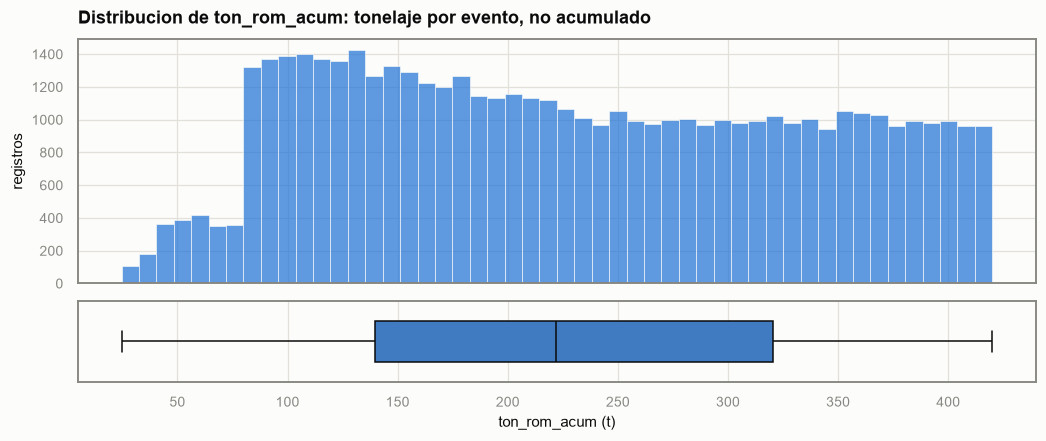

In [34]:
print(df["ton_rom_acum"].describe().round(2).to_string())
graficos.histograma_y_caja(df["ton_rom_acum"],
                           "Distribucion de ton_rom_acum: tonelaje por evento, no acumulado",
                           "ton_rom_acum (t)")

In [35]:
orden = df.sort_values("ts_opus_utc").assign(fecha_local=lambda d: (d["ts_opus_utc"] - pd.Timedelta(hours=5)).dt.date)
monotona = (orden.groupby(["frente_id", "fecha_local", "turno_cod"])["ton_rom_acum"]
                 .apply(lambda s: bool(s.is_monotonic_increasing)))
print(f"grupos frente x fecha x turno      : {len(monotona):,}")
print(f"con ton_rom_acum creciente         : {monotona.mean() * 100:.1f}%")
print(f"registros por grupo (mediana)      : {orden.groupby(['frente_id', 'fecha_local', 'turno_cod']).size().median():.0f}")

grupos frente x fecha x turno      : 4,019
con ton_rom_acum creciente         : 4.0%
registros por grupo (mediana)      : 14


In [36]:
# Un turno cualquiera, aislado: el de mas registros del extracto.
grupos = orden.groupby(["frente_id", "fecha_local", "turno_cod"])
clave = grupos.size().idxmax()
turno = grupos.get_group(clave).sort_values("ts_opus_utc")

print("turno aislado:", clave, f"({len(turno)} registros)")
print(turno[["ts_opus_utc", "ton_rom_acum", "ley_au_gpT"]].to_string(index=False))

saltos = turno["ton_rom_acum"].diff().dropna()
print()
print(f"descensos dentro del turno : {int((saltos < 0).sum())} de {len(saltos)} transiciones")
print(f"maximo del turno           : {turno['ton_rom_acum'].max():.2f} t")
print(f"suma del turno             : {turno['ton_rom_acum'].sum():.2f} t")

turno aislado: ('FR-C1-05', datetime.date(2025, 7, 2), 'N1') (18 registros)
        ts_opus_utc  ton_rom_acum  ley_au_gpT
2025-07-02 23:04:00    332.330000     10.3464
2025-07-02 23:27:00     53.434709     -1.0000
2025-07-02 23:48:00    162.700000      7.4846
2025-07-03 00:08:00    295.920000      7.7433
2025-07-03 00:29:00    116.840000     13.2254
2025-07-03 00:47:00    248.290000     10.0897
2025-07-03 01:09:00    347.600000     11.7791
2025-07-03 01:29:00    205.230000     13.1917
2025-07-03 01:45:00    129.050000      6.8893
2025-07-03 02:07:00    188.470000     12.9538
2025-07-03 02:22:00    322.180000     11.9196
2025-07-03 02:40:00    230.710000      7.7082
2025-07-03 03:09:00    414.230000      9.5108
2025-07-03 03:24:00    370.070000     10.5731
2025-07-03 03:45:00    216.640000     11.7338
2025-07-03 04:13:00    322.270000      8.5426
2025-07-03 04:28:00    100.020000     11.9693
2025-07-03 04:57:00    145.507201     10.6692

descensos dentro del turno : 8 de 17 transiciones

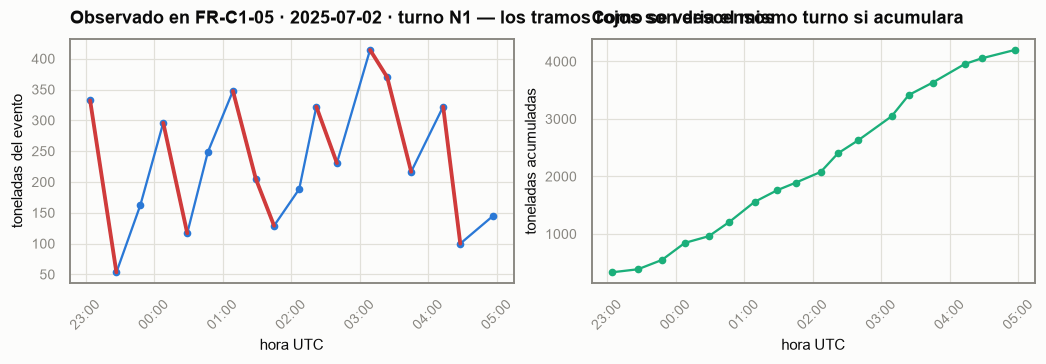

In [37]:
horas = turno["ts_opus_utc"]
valores = turno["ton_rom_acum"].to_numpy()
graficos.turno_aislado(horas, valores, f"{clave[0]} · {clave[1]} · turno {clave[2]}")

Aislando un turno se ve sin ambiguedad: en las dieciocho perforaciones del turno N1 del
2025-07-02 en FR-C1-05 el valor **baja en 8 de las 17 transiciones**, empieza en 332 t, sube a
414 t y termina en 146 t. Un contador acumulado no puede decrecer. Lo mismo a escala del
extracto completo: solo el 4% de los grupos frente-fecha-turno es creciente, y ese 4% es lo
que se espera por azar en grupos cortos.

El campo **no es un contador acumulado** pese a su nombre: es el tonelaje del evento
individual, entre 25 y 420 toneladas con media de 230. El panel derecho muestra como se veria
el mismo turno si de verdad acumulara. La consecuencia practica es que el tonelaje de un turno
se obtiene **sumando** los registros, no tomando el maximo: en este turno son 4201 t contra
las 414 t que daria leer el maximo como si fuera el acumulado final. El supuesto queda
declarado en lugar de heredado del nombre de la columna.

<a id="prod_estimada_oz"></a>

## 9. `prod_estimada_oz` — produccion estimada

El enunciado ya lo advierte entre parentesis: "calculada, no medida directamente". El dato
permite recuperar la formula exacta.

count    47190.000
mean        48.373
std         38.430
min          0.241
25%         20.151
50%         40.050
75%         69.086
max        265.496


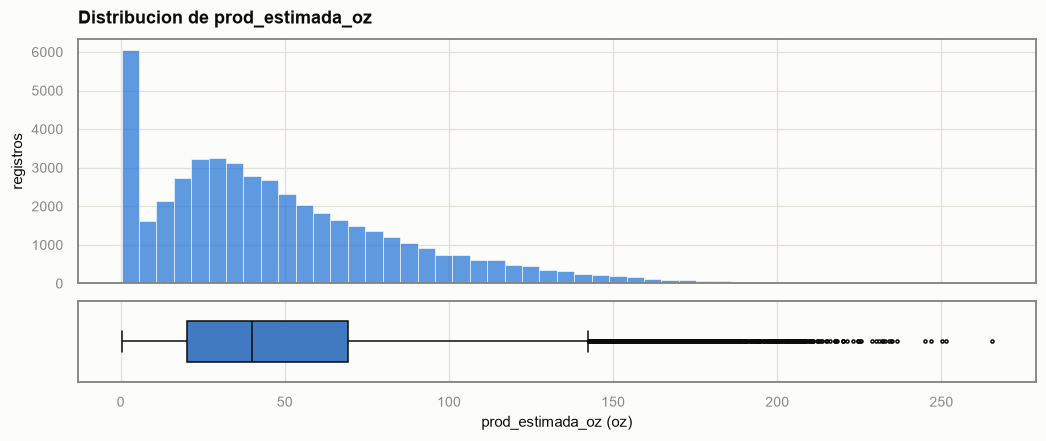

In [38]:
print(df["prod_estimada_oz"].describe().round(3).to_string())
graficos.histograma_y_caja(df["prod_estimada_oz"],
                           "Distribucion de prod_estimada_oz",
                           "prod_estimada_oz (oz)")

In [39]:
OZ_TROY_G = 31.1035
valida["ratio"] = valida["prod_estimada_oz"] / (valida["ley_au_gpT"] * valida["ton_rom_acum"] / OZ_TROY_G)
pd.crosstab(valida["tipo_mineral"], valida["ratio"].round(2)).replace(0, "")

ratio,0.10,0.83,0.87,0.91
tipo_mineral,,,,
EST,6730,,,
MIX,,13484,,
OX,,,13538,
SUL,,,,13438


In [40]:
RECUPERACION = {"OX": 0.87, "SUL": 0.91, "MIX": 0.83, "EST": 0.10}
reconstruida = (valida["ley_au_gpT"] * valida["ton_rom_acum"] / OZ_TROY_G
                * valida["tipo_mineral"].map(RECUPERACION))
residuo = reconstruida - valida["prod_estimada_oz"]
ss_res = float((residuo ** 2).sum())
ss_tot = float(((valida["prod_estimada_oz"] - valida["prod_estimada_oz"].mean()) ** 2).sum())

print("prod_estimada_oz = ley_au_gpT * ton_rom_acum / 31.1035 * recuperacion(tipo_mineral)")
print(f"  R2                 : {1 - ss_res / ss_tot:.12f}")
print(f"  error absoluto max : {residuo.abs().max():.2e} oz")
print()
print("nula exactamente donde la ley es centinela:",
      bool((df['prod_estimada_oz'].isna() == df['ley_sentinela']).all()))

prod_estimada_oz = ley_au_gpT * ton_rom_acum / 31.1035 * recuperacion(tipo_mineral)
  R2                 : 0.999999999972
  error absoluto max : 6.45e-04 oz

nula exactamente donde la ley es centinela: True


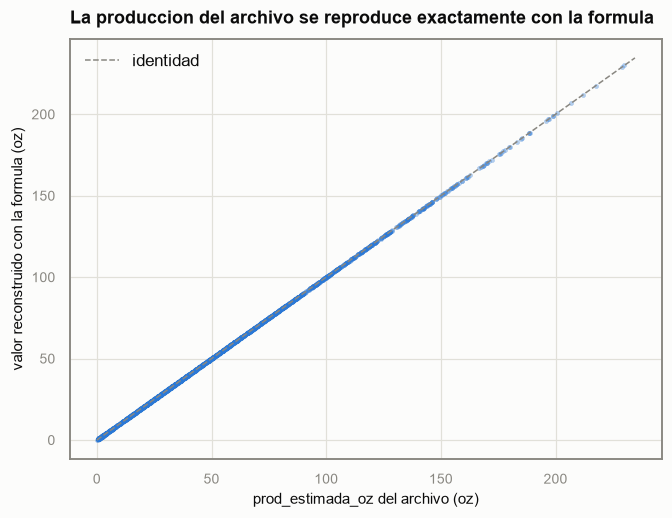

In [41]:
muestra = valida.sample(3000, random_state=7)
graficos.dispersion_identidad(
    muestra["prod_estimada_oz"], reconstruida.loc[muestra.index],
    "La produccion del archivo se reproduce exactamente con la formula",
    "prod_estimada_oz del archivo (oz)", "valor reconstruido con la formula (oz)")

La reconstruccion es exacta: `prod_estimada_oz = ley_au_gpT * ton_rom_acum / 31.1035 *
recuperacion(tipo_mineral)`, con R2 de 0.999999999972 y error maximo de 6.5e-4 oz, atribuible
al redondeo del archivo a cuatro decimales. Los factores de recuperacion metalurgica que
aparecen son OX 0.87, SUL 0.91, MIX 0.83 y EST 0.10, coherentes con el dominio: el esteril
recupera diez veces menos que el mineral.

No es entonces una variable independiente sino la propia ley multiplicada por el tonelaje y por
un factor que solo depende del tipo de mineral; despejando, `ley = prod_estimada_oz * 31.1035 /
(ton_rom_acum * recuperacion)`. La direccion de la dependencia la muestra la seccion 1: la
produccion es nula exactamente en los 2810 registros donde la ley es centinela, sin una sola
excepcion. La columna no acompana a la ley, se deriva de ella.

<a id="pres_hidraul_bar"></a>

## 10. `pres_hidraul_bar` — presion hidraulica

Rango normal publicado en el diccionario: 180 a 240 bar.

count    50000.00
mean       209.98
std         18.02
min        140.00
25%        197.90
50%        210.00
75%        222.10
max        270.00

correlacion con ley_au_gpT: +0.0033
limite del diccionario    : rango normal (180 a 240)
fuera de limite           : 4748 registros (9.50%)
tasa de falla fuera       : 4.32%
tasa de falla dentro      : 3.21%


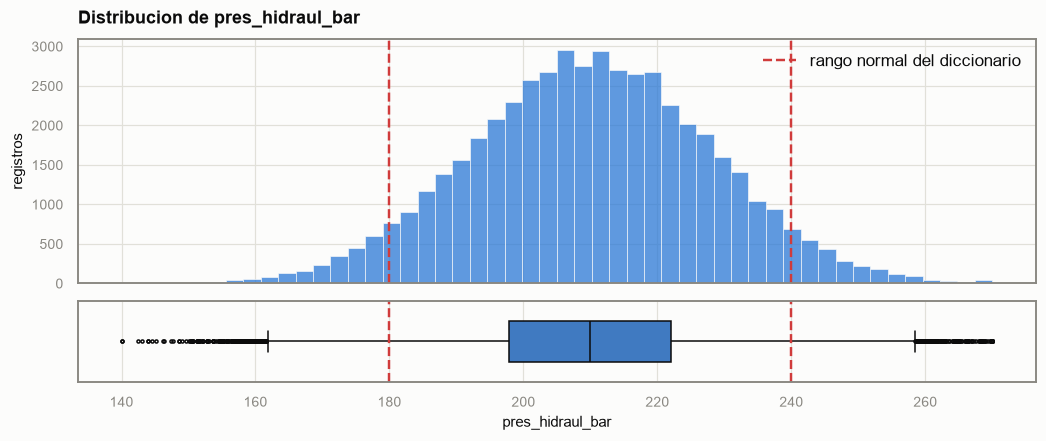

In [42]:
analisis.perfil_sensor("pres_hidraul_bar")

La presion sale de su banda en el 9.5% de los registros, por ambos extremos (140 a 270 bar
observados). Es la excedencia mas frecuente del extracto, pero la que menos discrimina: la tasa
de falla fuera de banda es 4.3% contra 3.3% de base.

<a id="rpm_corona"></a>

## 11. `rpm_corona` — revoluciones de la corona

Rango operacional publicado: 800 a 1400 rpm.

count    50000.00
mean      1099.81
std        161.02
min        820.00
25%        960.00
50%       1101.00
75%       1238.00
max       1379.00



correlacion con ley_au_gpT: -0.0060
limite del diccionario    : rango operacional (800 a 1400)
fuera de limite           : 0 registros (0.00%)
tasa de falla dentro      : 3.32%


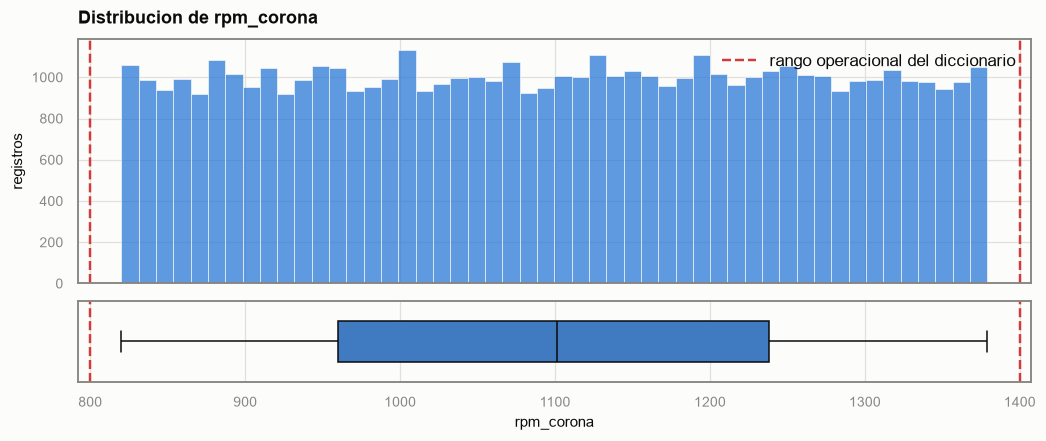

In [43]:
analisis.perfil_sensor("rpm_corona")

Ningun registro sale del rango: el observado es 820 a 1379 rpm. El limite parece impuesto por el
propio equipo, de modo que una bandera de excedencia sobre esta variable no separaria ningun
subconjunto del dato.

<a id="avance_mmin"></a>

## 12. `avance_mmin` — velocidad de avance

Metros por minuto de perforacion. El diccionario no publica un rango operacional para esta
variable, asi que solo cabe describir su distribucion.

count    50000.00
mean         1.80
std          0.40
min          0.30
25%          1.53
50%          1.80
75%          2.07
max          3.42

correlacion con ley_au_gpT: -0.0026


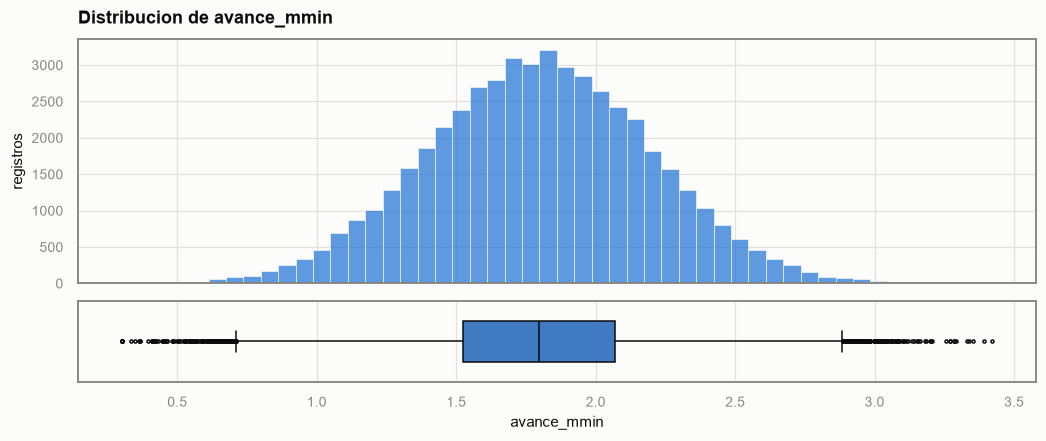

In [44]:
analisis.perfil_sensor("avance_mmin")

Distribucion simetrica alrededor de 1.8 m/min, entre 0.3 y 3.4, sin cola larga ni valores
imposibles. No correlaciona con la ley.

<a id="agua_iny_lmin"></a>

## 13. `agua_iny_lmin` — agua de inyeccion

Litros por minuto. Tampoco tiene rango publicado en el diccionario.

count    50000.00
mean        45.06
std         12.00
min          8.00
25%         36.96
50%         44.98
75%         53.18
max         90.00

correlacion con ley_au_gpT: -0.0048


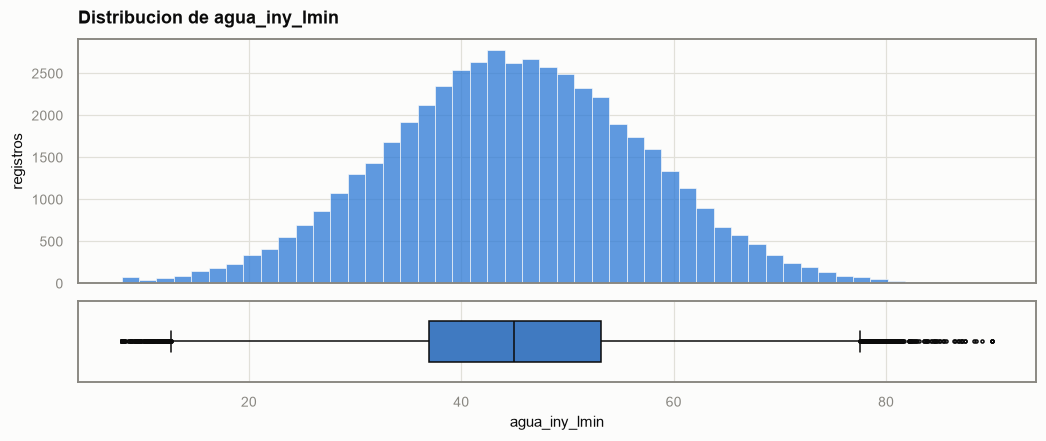

In [45]:
analisis.perfil_sensor("agua_iny_lmin")

Simetrica alrededor de 45 l/min, entre 8 y 90, sin anomalias de forma. No correlaciona con la
ley.

<a id="vibracion_rms_ms2"></a>

## 14. `vibracion_rms_ms2` — vibracion RMS

El diccionario fija 12 m/s2 como umbral de alerta operacional.

count    50000.00
mean         3.59
std          2.06
min          0.50
25%          2.07
50%          3.20
75%          4.71
max         19.62

correlacion con ley_au_gpT: +0.0044
limite del diccionario    : alerta operacional (12)
fuera de limite           : 140 registros (0.28%)
tasa de falla fuera       : 17.14%
tasa de falla dentro      : 3.28%


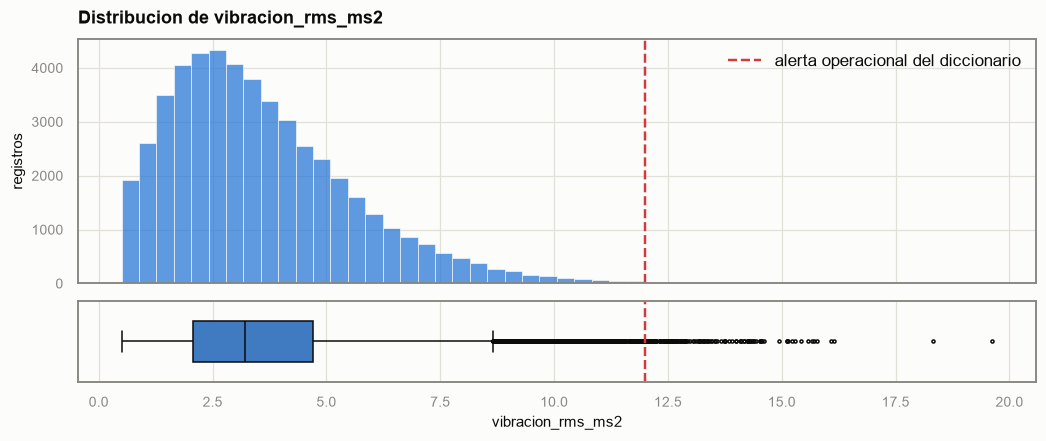

In [46]:
analisis.perfil_sensor("vibracion_rms_ms2")

Distribucion asimetrica con cola a la derecha hasta 19.6 m/s2. Solo 140 registros (0.28%) pasan
el umbral de alerta, pero ahi la tasa de falla es del 17.1%, cinco veces la base. Es un evento
raro y muy informativo.

In [47]:
# Donde esta el salto de la vibracion y si dice algo que la temperatura no diga ya.
for umbral in (10, 11, 12, 13):
    sobre = df["vibracion_rms_ms2"] > umbral
    print(f"vibracion > {umbral:2d} m/s2: n={int(sobre.sum()):5d} | "
          f"tasa de falla {df.loc[sobre, 'falla'].mean() * 100:5.2f}%")
print(f"linea base                : n={len(df):5d} | tasa de falla {df['falla'].mean() * 100:5.2f}%")
print()
for inferior, superior in [(12, 14), (14, 16), (16, 25)]:
    tramo = df["vibracion_rms_ms2"].between(inferior, superior, inclusive="left")
    print(f"  entre {inferior} y {superior} m/s2: n={int(tramo.sum()):4d} | "
          f"tasa de falla {df.loc[tramo, 'falla'].mean() * 100:5.2f}%")
print()
alerta_vibracion = df["vibracion_rms_ms2"] > 12
alerta_temperatura = df["temp_motor_c"] > 95
print(f"registros con las dos alertas a la vez: {int((alerta_vibracion & alerta_temperatura).sum())} "
      f"de {int(alerta_vibracion.sum())} ({(alerta_vibracion & alerta_temperatura).sum() / alerta_vibracion.sum() * 100:.1f}% "
      f"de los que superan la vibracion)")

vibracion > 10 m/s2: n=  505 | tasa de falla  6.93%
vibracion > 11 m/s2: n=  269 | tasa de falla  9.67%
vibracion > 12 m/s2: n=  140 | tasa de falla 17.14%
vibracion > 13 m/s2: n=   64 | tasa de falla 18.75%
linea base                : n=50000 | tasa de falla  3.32%

  entre 12 y 14 m/s2: n= 104 | tasa de falla 16.35%
  entre 14 y 16 m/s2: n=  32 | tasa de falla 18.75%
  entre 16 y 25 m/s2: n=   4 | tasa de falla 25.00%

registros con las dos alertas a la vez: 27 de 140 (19.3% de los que superan la vibracion)


El umbral de 12 m/s2 que publica el diccionario coincide con el salto real: la tasa de falla
pasa de 6.9% sobre 10 m/s2 a 9.7% sobre 11 y a **17.1% sobre 12**. No es un corte arbitrario
heredado del manual, es donde el dato cambia de comportamiento.

Dos precisiones para usarla. La magnitud del exceso apenas discrimina —16.4% entre 12 y 14
m/s2, 18.8% entre 14 y 16, 25% por encima con solo cuatro registros—, asi que con 140 casos la
bandera es lo unico que el dato sostiene; una feature continua le pediria al modelo una
pendiente que no puede estimar. Y la alerta **no repite lo que dice la temperatura**: solo 27
de esos 140 registros superan tambien los 95 C, el 19%. Son dos poblaciones distintas.

<a id="temp_motor_c"></a>

## 15. `temp_motor_c` — temperatura de motor

El diccionario fija 95 C como umbral de apagado automatico.

count    50000.00
mean        71.94
std         10.95
min         38.00
25%         64.50
50%         72.00
75%         79.40
max        108.49

correlacion con ley_au_gpT: -0.0048
limite del diccionario    : apagado automatico (95)
fuera de limite           : 922 registros (1.84%)
tasa de falla fuera       : 22.02%
tasa de falla dentro      : 2.97%


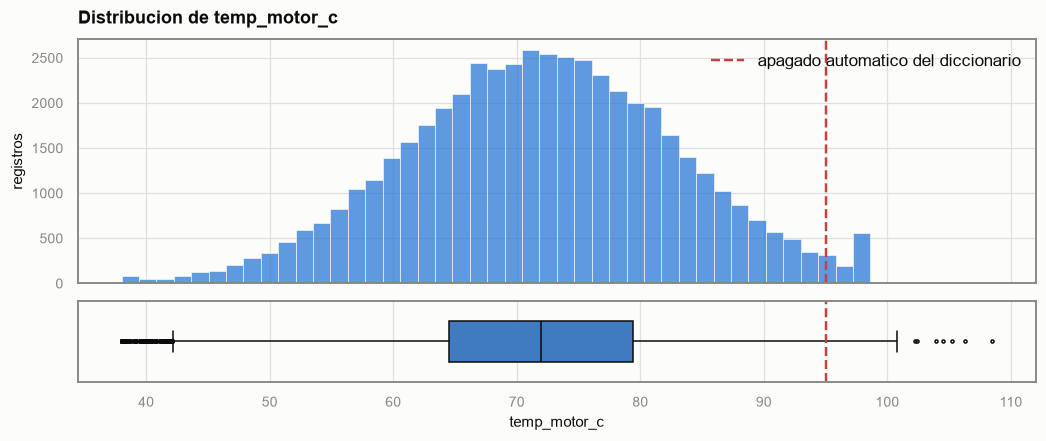

In [48]:
analisis.perfil_sensor("temp_motor_c")

In [49]:
# Donde empieza realmente el riesgo termico, grado a grado.
tramos = pd.DataFrame([
    {"tramo": f"{inferior}-{superior} C",
     "registros": int(df["temp_motor_c"].between(inferior, superior, inclusive="left").sum()),
     "tasa_falla_pct": round(df.loc[df["temp_motor_c"].between(inferior, superior, inclusive="left"),
                                    "falla"].mean() * 100, 2)}
    for inferior, superior in [(0, 60), (60, 70), (70, 80), (80, 85), (85, 87), (87, 88),
                               (88, 89), (89, 90), (90, 93), (93, 95), (95, 97), (97, 200)]
])
print(tramos.to_string(index=False))
print(f"linea base: {df['falla'].mean() * 100:.2f}%")

   tramo  registros  tasa_falla_pct
  0-60 C       6912            1.84
 60-70 C      14317            1.70
 70-80 C      17063            1.88
 80-85 C       5810            1.93
 85-87 C       1559            1.86
 87-88 C        674            1.34
 88-89 C        598           22.24
 89-90 C        494           23.48
 90-93 C       1147           21.36
 93-95 C        481           23.49
 95-97 C        330           21.52
97-200 C        615           22.76
linea base: 3.32%


In [50]:
# El umbral del diccionario contra el umbral que muestran los datos.
comparacion_umbrales = pd.DataFrame([
    {"umbral_C": umbral,
     "registros": int((df["temp_motor_c"] > umbral).sum()),
     "pct_del_extracto": round((df["temp_motor_c"] > umbral).mean() * 100, 1),
     "tasa_falla_pct": round(df.loc[df["temp_motor_c"] > umbral, "falla"].mean() * 100, 2),
     "captura_de_las_fallas_pct": round(
         df.loc[df["temp_motor_c"] > umbral, "falla"].sum() / df["falla"].sum() * 100, 1)}
    for umbral in (85, 87, 88, 90, 95)
])
print(comparacion_umbrales.to_string(index=False))
print()
sobre_apagado = df.loc[df["temp_motor_c"] > 95].assign(exceso=lambda d: d["temp_motor_c"] - 95)
print("dentro de los que superan 95 C, por magnitud del exceso:")
for inferior, superior in [(0, 1), (1, 2), (2, 4), (4, 20)]:
    tramo = sobre_apagado["exceso"].between(inferior, superior, inclusive="left")
    print(f"  exceso de {inferior} a {superior} C: n={int(tramo.sum()):4d} | "
          f"tasa de falla {sobre_apagado.loc[tramo, 'falla'].mean() * 100:5.2f}%")
print(f"corr(exceso sobre 95 C, falla): {sobre_apagado['exceso'].corr(sobre_apagado['falla'].astype(float)):+.4f}")

 umbral_C  registros  pct_del_extracto  tasa_falla_pct  captura_de_las_fallas_pct
       85       5824              11.6           14.68                       51.5
       87       4268               8.5           19.35                       49.8
       88       3602               7.2           22.68                       49.2
       90       2533               5.1           22.15                       33.8
       95        922               1.8           22.02                       12.2

dentro de los que superan 95 C, por magnitud del exceso:
  exceso de 0 a 1 C: n= 169 | tasa de falla 23.08%
  exceso de 1 a 2 C: n= 138 | tasa de falla 17.39%
  exceso de 2 a 4 C: n= 598 | tasa de falla 22.74%
  exceso de 4 a 20 C: n=  17 | tasa de falla 23.53%
corr(exceso sobre 95 C, falla): +0.0246


**El umbral real no es 95 C, es 88 C.** Grado a grado la relacion es un escalon, no una rampa:
hasta 87 C la tasa de falla ronda el 2%, entre 88 y 89 salta a 22.2% y de ahi en adelante se
queda en una meseta plana que ya no crece. El apagado automatico que publica el diccionario
esta siete grados por encima de donde el riesgo empieza.

La diferencia no es cosmetica. El umbral de 88 C marca el 7.2% del extracto con una tasa de
falla del 22.7% y **captura el 49% de todas las fallas**; el de 95 C marca el 1.8% con la misma
tasa y captura solo el 12%. Cuatro veces mas eventos identificados con la misma precision.

Por encima del umbral, la magnitud del exceso no dice nada: la correlacion entre cuantos grados
se pasa y que haya falla es +0.02, y los tramos de exceso tienen todos la misma tasa. Una
bandera representa la relacion; una feature continua del exceso, no.

Es tambien un hallazgo con lectura operacional directa: si el apagado automatico se dispara
recien a 95 C, el equipo pasa por una franja de siete grados donde el riesgo ya se multiplico
por diez sin que nada lo detenga. Vale la pena reportarlo a mantenimiento.

922 registros (1.8%) superan el umbral de apagado y ahi la tasa de falla es del 22.0%, casi
siete veces la base. Es la asociacion mas fuerte del extracto, y conviene enunciarla con
precision: temperatura y falla estan **en el mismo registro**, de modo que lo medido es
coocurrencia dentro de la fila y no que la temperatura anteceda a la falla. El archivo no
contiene ninguna evidencia de precedencia temporal entre las dos. La comparacion de
distribuciones con y sin falla esta en la seccion 16.

<a id="falla_cod"></a>

## 16. `falla_cod` — codigo de falla, el objetivo de clasificacion

Nulo significa operacion normal, de modo que la columna define implicitamente el evento de
falla. El prefijo del codigo identifica el subsistema.

In [51]:
df["falla"] = df["falla_cod"].notna()
print(f"prevalencia global: {df['falla'].mean() * 100:.2f}%  ({int(df['falla'].sum())} de {len(df):,})")
print()
codigos = df["falla_cod"].value_counts().rename_axis("codigo").to_frame("eventos")
codigos["subsistema"] = codigos.index.str.split("-").str[1]
print(codigos.to_string())

prevalencia global: 3.32%  (1659 de 50,000)

            eventos subsistema
codigo                        
E-ELEC-01       227       ELEC
M-MOTOR-07      219      MOTOR
H-HIDRA-02      210      HIDRA
B-BOMBA-01      209      BOMBA
H-HIDRA-05      202      HIDRA
M-MOTOR-03      202      MOTOR
S-SELLO-02      198      SELLO
E-ELEC-04       192       ELEC


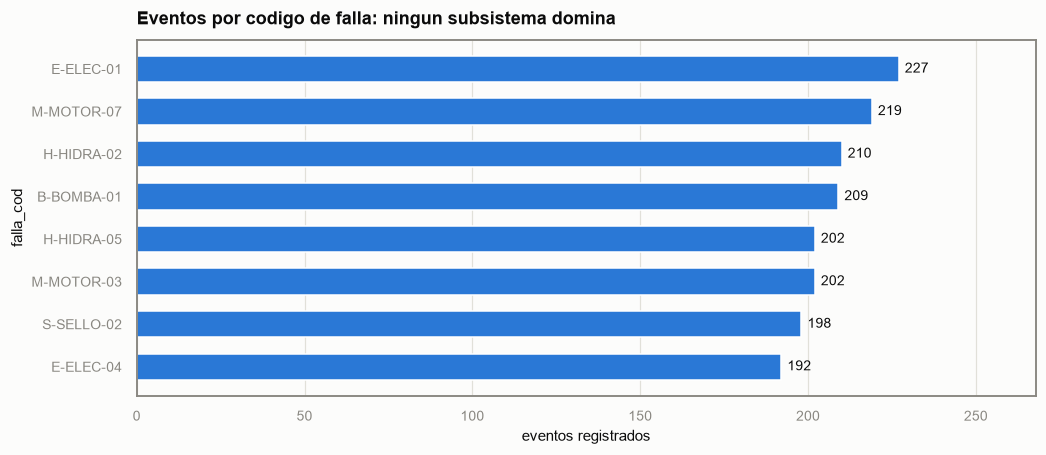

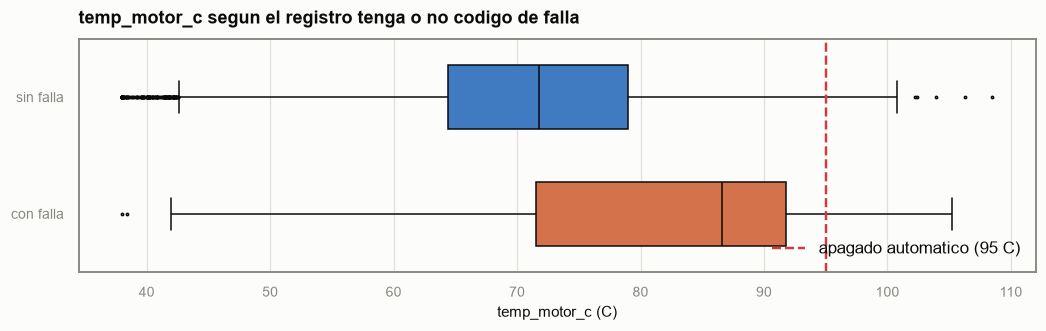

In [52]:
codigos_falla = df["falla_cod"].value_counts()
graficos.barras_horizontales(
    codigos_falla.index[::-1].to_list(), codigos_falla.to_numpy()[::-1],
    "Eventos por codigo de falla: ningun subsistema domina",
    "eventos registrados", "falla_cod", formato="{:,.0f}")

graficos.cajas_por_grupo(
    {"sin falla": df.loc[~df["falla"], "temp_motor_c"],
     "con falla": df.loc[df["falla"], "temp_motor_c"]},
    "temp_motor_c segun el registro tenga o no codigo de falla",
    "temp_motor_c (C)", limites=(95.0,), etiqueta_limite="apagado automatico (95 C)")

In [53]:
comparacion_falla = (df.groupby("falla")[["temp_motor_c", "vibracion_rms_ms2", "pres_hidraul_bar",
                                          "rpm_corona", "avance_mmin", "agua_iny_lmin"]]
                       .mean().T)
comparacion_falla.columns = ["sin falla", "con falla"]
comparacion_falla["delta"] = comparacion_falla["con falla"] - comparacion_falla["sin falla"]
comparacion_falla.round(2)

,sin falla,con falla,delta
temp_motor_c,71.61,81.38,9.76
vibracion_rms_ms2,3.59,3.72,0.13
pres_hidraul_bar,210.01,209.13,-0.88
rpm_corona,1099.78,1100.65,0.86
avance_mmin,1.80,1.79,-0.01
agua_iny_lmin,45.06,44.95,-0.11


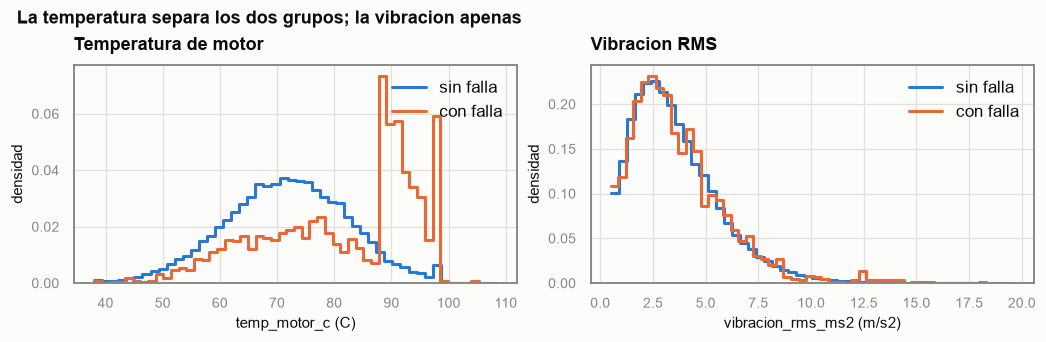

In [54]:
graficos.densidades_por_falla(
    df, df["falla"],
    [("temp_motor_c", "temp_motor_c (C)", "Temperatura de motor"),
     ("vibracion_rms_ms2", "vibracion_rms_ms2 (m/s2)", "Vibracion RMS")],
    "La temperatura separa los dos grupos; la vibracion apenas")

In [55]:
condiciones = {
    "temp_motor_c > 95": df["temp_motor_c"] > 95,
    "vibracion_rms_ms2 > 12": df["vibracion_rms_ms2"] > 12,
    "presion fuera de 180-240": ~df["pres_hidraul_bar"].between(180, 240),
    "flag_mant_prev = 1": df["flag_mant_prev"].eq(1),
    "linea base (todos)": pd.Series(True, index=df.index),
}
pd.DataFrame([
    {"condicion": nombre,
     "registros": int(mascara.sum()),
     "tasa_falla_pct": round(df.loc[mascara, "falla"].mean() * 100, 2)}
    for nombre, mascara in condiciones.items()
])

,condicion,registros,tasa_falla_pct
0,temp_motor_c > 95,922,22.02
1,vibracion_rms_ms2 > 12,140,17.14
2,presion fuera de 180-240,4748,4.32
3,flag_mant_prev = 1,1213,2.80
4,linea base (todos),50000,3.32


In [56]:
# El objetivo del modulo de clasificacion es la falla en las proximas 4 horas del mismo equipo.
VENTANA_ANTICIPACION = pd.Timedelta(hours=4)

def falla_en_ventana(marco: pd.DataFrame) -> pd.Series:
    """Marca cada registro segun haya una falla del mismo equipo en las proximas 4 horas."""
    objetivo = pd.Series(False, index=marco.index)
    for _, eventos in marco.groupby("equipo_id", sort=False):
        instantes = eventos["ts_opus_utc"].to_numpy()
        fallas = eventos.loc[eventos["falla"], "ts_opus_utc"].to_numpy()
        for posicion, momento in zip(eventos.index, instantes, strict=True):
            objetivo.loc[posicion] = bool(
                ((fallas > momento) & (fallas <= momento + VENTANA_ANTICIPACION)).any())
    return objetivo

df["falla_4h"] = falla_en_ventana(df)
minutos_entre_eventos = (df.sort_values("ts_opus_utc").groupby("equipo_id")["ts_opus_utc"]
                           .diff().dt.total_seconds().div(60).median())
print(f"prevalencia de falla en las proximas 4 h: {df['falla_4h'].mean() * 100:.2f}%")
print(f"minutos entre eventos del mismo equipo (mediana): {minutos_entre_eventos:.0f}")

prevalencia de falla en las proximas 4 h: 3.05%
minutos entre eventos del mismo equipo (mediana): 173


In [57]:
# Alguna condicion observable anticipa esa falla?
condiciones = {
    "falla en el registro actual": df["falla"],
    "temp_motor_c > 88": df["temp_motor_c"] > 88,
    "temp_motor_c > 95": df["temp_motor_c"] > 95,
    "vibracion_rms_ms2 > 12": df["vibracion_rms_ms2"] > 12,
    "presion fuera de 180-240": ~df["pres_hidraul_bar"].between(180, 240),
    "flag_mant_prev = 1": df["flag_mant_prev"].eq(1),
}
print(pd.DataFrame([
    {"condicion": nombre, "registros": int(mascara.sum()),
     "tasa_falla_4h_pct": round(df.loc[mascara, "falla_4h"].mean() * 100, 2),
     "tasa_falla_mismo_registro_pct": round(df.loc[mascara, "falla"].mean() * 100, 2)}
    for nombre, mascara in condiciones.items()
]).to_string(index=False))
print(f"linea base: falla_4h {df['falla_4h'].mean() * 100:.2f}% | "
      f"mismo registro {df['falla'].mean() * 100:.2f}%")
print()
orden_temporal = df.sort_values("ts_opus_utc")
for columna in ["temp_motor_c", "vibracion_rms_ms2", "pres_hidraul_bar"]:
    anterior = orden_temporal.groupby("equipo_id", sort=False)[columna].shift(1)
    print(f"corr({columna}, su valor anterior en el mismo equipo): "
          f"{orden_temporal[columna].corr(anterior):+.4f}")

                  condicion  registros  tasa_falla_4h_pct  tasa_falla_mismo_registro_pct
falla en el registro actual       1659               3.19                         100.00
          temp_motor_c > 88       3602               3.11                          22.68
          temp_motor_c > 95        922               3.36                          22.02
     vibracion_rms_ms2 > 12        140               4.29                          17.14
   presion fuera de 180-240       4748               3.26                           4.32
         flag_mant_prev = 1       1213               3.13                           2.80
linea base: falla_4h 3.05% | mismo registro 3.32%

corr(temp_motor_c, su valor anterior en el mismo equipo): +0.0044
corr(vibracion_rms_ms2, su valor anterior en el mismo equipo): -0.0107
corr(pres_hidraul_bar, su valor anterior en el mismo equipo): -0.0005


**El objetivo tal como lo define el enunciado —falla en las proximas cuatro horas— no es
predecible en este extracto.** Ninguna condicion observable mueve la tasa: con una prevalencia
base de 3.05%, estar sobre 88 C da 3.11%, sobre 95 C da 3.36%, la vibracion alta da 4.29% sobre
140 registros y haber fallado recien da 3.19%. La correlacion de la temperatura con la falla es
0.16 **en el mismo registro** y 0.0015 **a cuatro horas**.

La explicacion esta en dos hechos ya medidos. Los sensores no tienen persistencia —la
correlacion de la temperatura con su propio valor anterior en el mismo equipo es 0.004— asi que
no hay estado que se arrastre de un registro al siguiente; y cada equipo registra un evento
cada tres horas, de modo que "las proximas cuatro horas" son uno o dos eventos, cada uno
sorteado de forma independiente.

Lo que si funciona es la **deteccion contemporanea**: la condicion del propio registro separa
con claridad (22.7% de falla sobre 88 C contra 3.3% de base). El contraste entre las dos
columnas de la tabla es el resultado: hay senal para reconocer un equipo en problemas ahora, y
no la hay para anticiparlo con cuatro horas.

Es una limitacion del extracto y no del metodo, y conviene declararla antes de elegir metrica:
un clasificador a cuatro horas sobre estos datos no puede superar de forma consistente la tasa
base, y presentarlo como si lo hiciera seria un error de lectura, no un logro.

La falla es un evento raro: 3.32% de los registros, 1659 eventos repartidos en ocho codigos de
cinco subsistemas (electrico, motor, hidraulico, bomba y sello) con frecuencias muy parejas,
entre 192 y 227 eventos cada uno. Ningun subsistema domina, y esa uniformidad es en si misma
coherente con el supuesto de la seccion 2.

La temperatura de motor es la unica variable que separa con claridad: casi diez grados de
diferencia en media (81.4 C con falla contra 71.6 C sin) y 22% de tasa de falla sobre el umbral
de apagado. La vibracion separa poco en media, aunque sus excedencias tambien multiplican por
cinco la tasa. La presion fuera de banda casi no discrimina. Las tres son asociaciones dentro
del mismo registro: el archivo no permite decir que una condicion preceda a la falla, solo que
aparece junto a ella.

<a id="flag_mant_prev"></a>

## 17. `flag_mant_prev` — ventana de mantenimiento preventivo

Bandera binaria: 1 si el registro cae dentro de una ventana de mantenimiento preventivo.

registros con flag_mant_prev = 1: 1213 (2.43%)

                registros  tasa_falla_pct
flag_mant_prev                           
0                   48787            3.33
1                    1213            2.80

z = -1.01 | p-valor bilateral = 0.31
IC95 de la tasa dentro del grupo: 1.87% a 3.73%  (tasa base 3.32%)


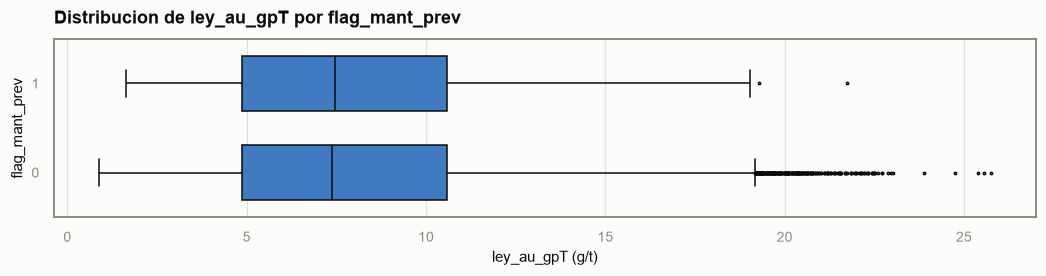

,registros,ley_media,falla_pct
flag_mant_prev,,,
0,48787,8.00,3.33
1,1213,7.97,2.80


In [58]:
print(f"registros con flag_mant_prev = 1: {int(df['flag_mant_prev'].sum())} "
      f"({df['flag_mant_prev'].mean() * 100:.2f}%)")
print()
print(df.groupby("flag_mant_prev")["falla"]
        .agg(registros="size", tasa_falla_pct=lambda s: s.mean() * 100).round(2).to_string())
print()
print(analisis.prueba_dos_proporciones(df["flag_mant_prev"].eq(1)))

tabla_mant = analisis.perfil_categorica("flag_mant_prev", conteo=False)
display(tabla_mant)

Solo el 2.4% de los registros cae dentro de una ventana preventiva, y ahi la tasa de falla es
2.80% contra 3.33% fuera. La diferencia parece favorable al preventivo, pero **no se distingue
del azar**: con 1213 registros dentro de ventana, la prueba de dos proporciones da z = -1.01 y
p = 0.31, y el intervalo de confianza del 95% para la tasa dentro de ventana va de 1.87% a
3.73%, es decir contiene la tasa base. No hay efecto medible, ni a favor ni en contra.

Que no lo haya no autoriza a concluir que el programa preventivo de la unidad minera no
funciona. Bajo el supuesto de la seccion 2, `flag_mant_prev` es una etiqueta mas repartida
sobre el flujo, y lo unico que se puede afirmar es que en este archivo la bandera no separa
ningun subconjunto: es una columna sin poder discriminante, no un diagnostico de la operacion.

<a id="equipo_id"></a>

## 18. `equipo_id` — equipo de perforacion

Diez equipos de tres fabricantes (ATLAS, BOAR, SAND), con unos 5000 registros cada uno.

frentes distintos por equipo: [13]
tasa de falla por equipo_id: observado 2.81% a 3.61% | esperado solo por muestreo con n=5000: 2.82% a 3.81%


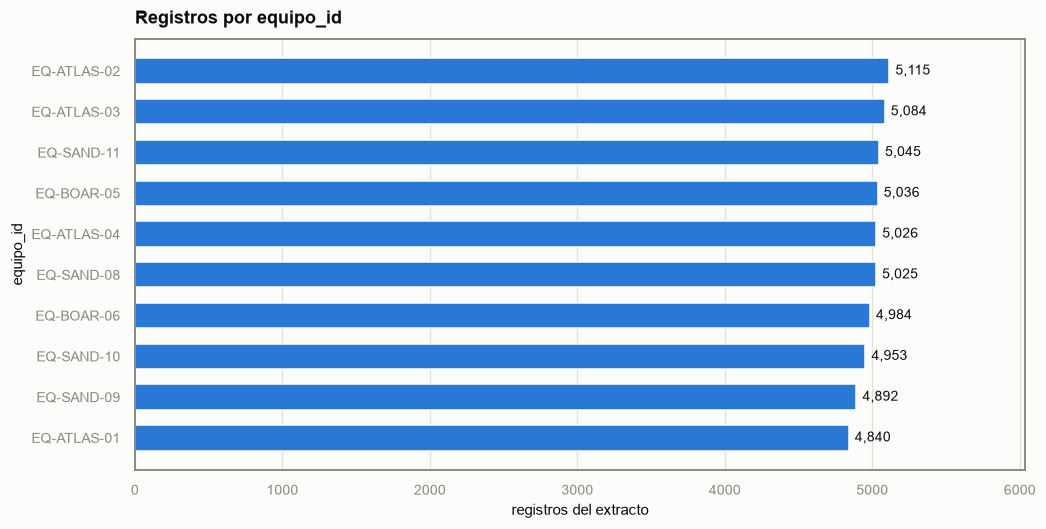

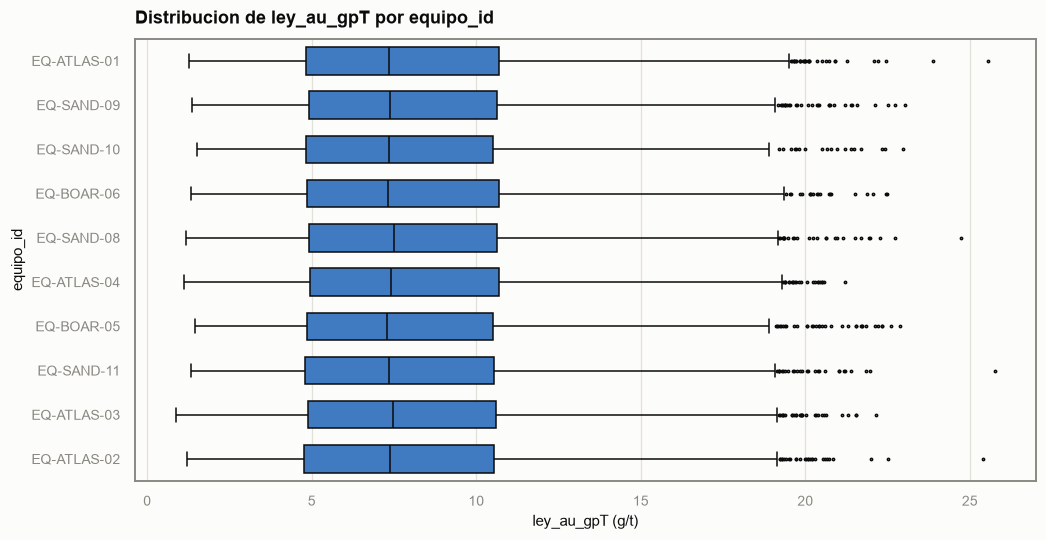

,registros,ley_media,falla_pct
equipo_id,,,
EQ-ATLAS-02,5115,7.94,3.44
EQ-ATLAS-03,5084,8.02,3.36
EQ-SAND-11,5045,7.95,3.37
EQ-BOAR-05,5036,7.95,3.61
EQ-ATLAS-04,5026,8.06,3.30
EQ-SAND-08,5025,8.05,3.36
EQ-BOAR-06,4984,8.01,3.15
EQ-SAND-10,4953,7.91,2.81
EQ-SAND-09,4892,8.04,3.35


In [59]:
print("frentes distintos por equipo:", df.groupby("equipo_id")["frente_id"].nunique().unique())
print(analisis.banda_esperada("equipo_id"))

tabla_equipo = analisis.perfil_categorica("equipo_id")
display(tabla_equipo)

Cada equipo trabaja en los trece frentes, asi que el equipo no esta confundido con la
ubicacion: la ley media por equipo es plana (7.91 a 8.06 g/t). Las fallas se reparten entre
2.81% y 3.61%, indistinguible de lo que produce el muestreo: con unos 5000 registros por equipo
y una tasa base de 3.32%, el 95% de las estimaciones deberia caer entre 2.82% y 3.81%. El
extremo inferior observado roza el borde de esa banda, que es justo lo que se espera al comparar
diez categorias contra un intervalo del 95%. No hay diferencia entre equipos que explicar.

Leido bajo el supuesto adoptado en la seccion 2, esto no es un hallazgo operacional sino su
consecuencia: `equipo_id` es una etiqueta repartida sobre un flujo serial, no un activo fisico
con historia propia. La lectura correcta no es "no hay un equipo problematico" sino **la columna
no permite decir nada sobre los equipos**, ni a favor ni en contra.

<a id="op_id"></a>

## 19. `op_id` — operador

Dieciocho operadores identificados con un hash corto, unos 2780 registros cada uno.

equipos distintos por operador: [10]
tasa de falla por op_id: observado 2.46% a 3.89% | esperado solo por muestreo con n=2778: 2.65% a 3.98%


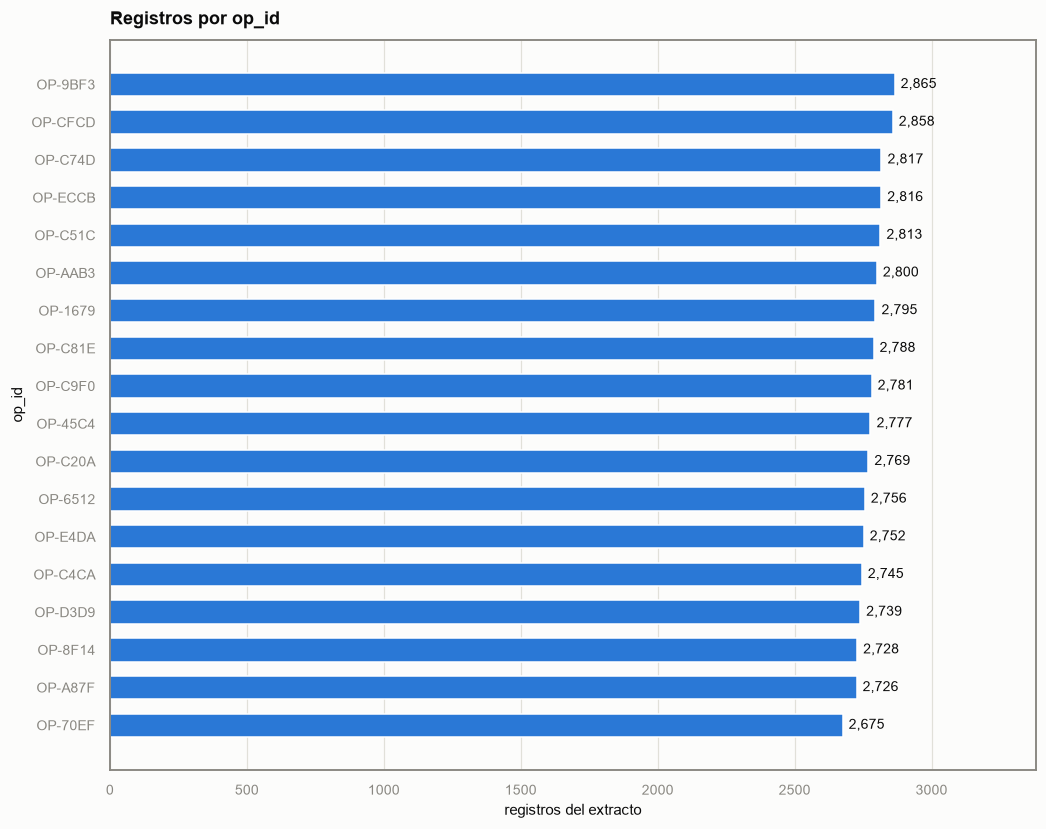

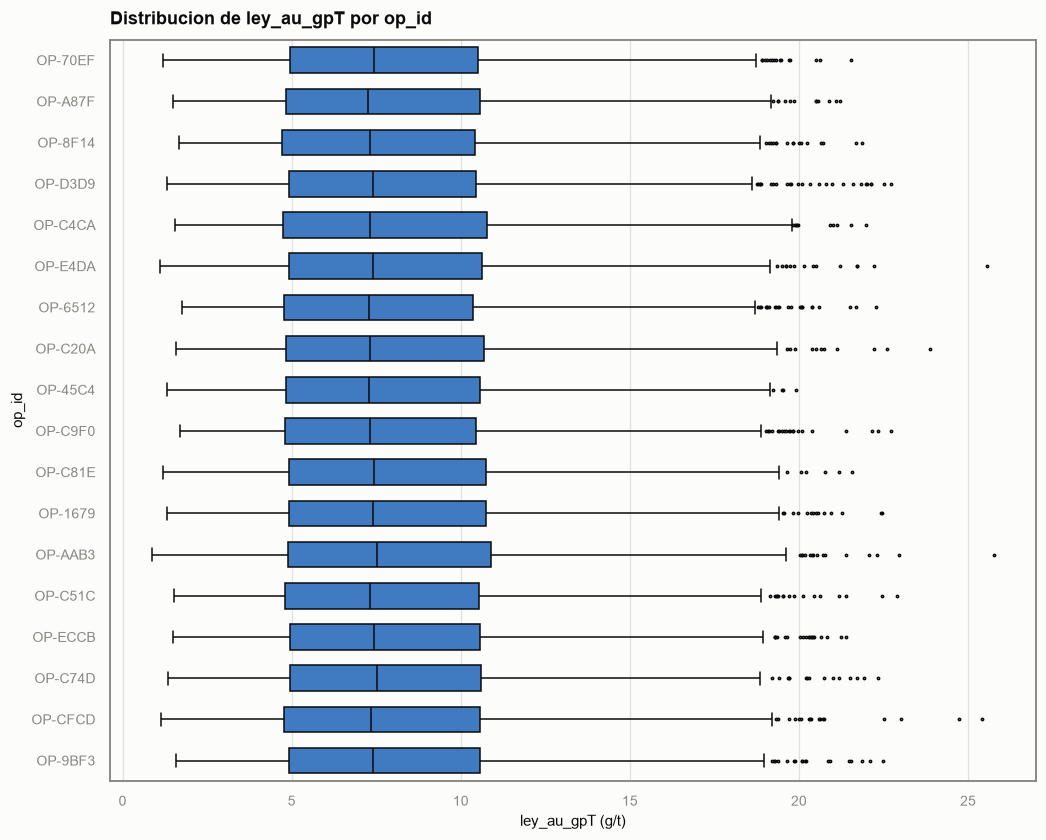

,registros,ley_media,falla_pct
op_id,,,
OP-9BF3,2865,8.01,3.04
OP-CFCD,2858,7.98,3.22
OP-C74D,2817,8.09,3.16
OP-ECCB,2816,8.02,3.59
OP-C51C,2813,7.98,3.34
OP-AAB3,2800,8.15,3.21
OP-1679,2795,8.01,3.65
OP-C81E,2788,8.04,3.26
OP-C9F0,2781,7.99,3.70


In [60]:
print("equipos distintos por operador:", df.groupby("op_id")["equipo_id"].nunique().unique())
print(analisis.banda_esperada("op_id"))

tabla_operador = analisis.perfil_categorica("op_id")
display(tabla_operador)

Cada operador pasa por los diez equipos, de modo que tampoco esta confundido con el activo. La
ley media por operador es plana (7.90 a 8.15 g/t) y la tasa de falla va de 2.46% a 3.89%,
practicamente lo que produce el muestreo: con unos 2778 registros por operador la banda del 95%
alrededor de la base es de 2.65% a 3.98%. El minimo queda apenas por debajo, y con dieciocho
categorias comparadas contra un intervalo del 95% lo raro seria que ninguna se saliera.

Vale la misma lectura que para `equipo_id`: bajo el supuesto de la seccion 2, `op_id` es una
etiqueta sin contenido y no soporta ninguna afirmacion sobre el desempeno de las cuadrillas.